In this notebook v9:
- AUC ROC curve (specific for IJCNN)

Already done before:
- AUC ROC curve continuation (v8)
- AUC ROC curve (v7)
- Test the use of another dataset for COVID (v6)
- LOAD the new models created for COVID (v6)
- Test the use of another dataset for COVID (v5)
- covid, pneumonia and normal lung (v5)
- create models for each one of them (v5)
- Test segmentation performance (v4)
- Removing autoencoder evaluation (to simplify the notebook) (v4)
- Results aquisition for segmentator and for autoencoder ensemble (v4)
- separate functions and evaluation methods
- deal_with_ood()
- Testing adding new domain.
- Focused only on majority voting
- Downgrade to 2.15.0 required

Other Colab resources (v7)
- [DeepSAM - random dataset split.ipynb](https://colab.research.google.com/drive/1KWllIbfF-yFDmjV1ULpUHzahcjmD8TSX#scrollTo=BlcDz7H39c37)
- [[experiment] Transform coco polygon annotatiojn into png images.ipynb](https://colab.research.google.com/drive/1Ew3S2IfcLat0MNM3tpzKeDnsvLdGE_2U#scrollTo=tmHpnoc_jJAT)
- [DeepSAM - open brain tumor segmentation dataset.ipynb](https://colab.research.google.com/drive/1MBR5EcErqjPFQrMy45DOnCa9Hoe4Evj6#scrollTo=3_8W3G2brRXy)
- [Sort_Google_Scholar_No_Code_Version.ipynb](https://colab.research.google.com/drive/1HCqi62pBsma8flpjCMmhZWL0bO6RbIz5#scrollTo=qgfQT7i2XrPf)

# SETUP

## Downgrade Tensorflow

In [ ]:
# https://www.tensorflow.org/versions#tensorflow_2
#  Downgrade required as on 2.16.1 onwards the build() method is required.
#  Required is not a problem, but implementing it, the gpu goes out of memory when training the autoencoder
#  so, the best option is (today) downgrade :)
!pip install tensorflow==2.15.0 --quiet
!pip install tensorflow-gpu==2.15.0 --quiet
!pip install ipython-autotime --quiet
%load_ext autotime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 6.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorstore 0.1.71 requires ml_dtypes>=0.3.1, but you have ml-dtypes 0.2.0 which is incompatible.
tf-keras 2.17.0 requires tensorflow<2.18,>=2.17, but you have tensorflow 2.15.0 which is incompatible.
ERROR: Could not find a version that satisfies the requirement tensorflow-gpu==2.15.0 (from versions: 2.8.0rc0, 2.8.0rc1, 2.8.0, 2.8.1, 2.8.2, 2.8.3, 2.8.

## Dependencies

In [ ]:
from google.colab import output # Play an audio beep. Any audio URL will do.
from google.colab import drive
from google.colab import files
from google.colab import runtime

from skimage import exposure, color
from matplotlib import pyplot
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

from tensorflow.keras import layers, losses, models
from tensorflow.keras.models import save_model, Model
from tensorflow.keras.layers import Input ,BatchNormalization , Activation, Conv2D, UpSampling2D, MaxPooling2D, concatenate
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.optimizers import Adam, Adagrad, RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt
import os
import cv2
import glob
import math
import random
import numpy as np
import pandas as pd
import seaborn as sns
import skimage.transform as trans
import tensorflow as tf
import tensorflow.keras.backend as K

print(tf.__version__)

drive.mount('/content/drive')

# from keras.optimizers import Adam
# import tensorflow as tf

# Autoencoder

selected_layers = ['block2_conv2',"block3_conv3",'block4_conv3']
selected_layer_weights = [2.0 , 4.0 , 8.0]

vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet', input_shape=(64, 64, 3))
vgg.trainable = False  # Freeze the VGG model
outputs = [vgg.get_layer(l).output for l in selected_layers]
feature_extractor = Model(vgg.input, outputs)

def alert():
  output.eval_js('new Audio("https://upload.wikimedia.org/wikipedia/commons/0/05/Beep-09.ogg").play()')

# @tf.function
@tf.function(input_signature=(tf.TensorSpec(shape=(1, 64, 64, 3), dtype=tf.float32, name=None),tf.TensorSpec(shape=(None, None, None, 3), dtype=tf.float32, name=None)))
# TensorSpec(shape=(None, None, None, None), dtype=tf.float32, name=None)
# TensorSpec(shape=(1, 64, 64, 3), dtype=tf.float32, name=None)
def perceptual_loss(input_image , reconstruct_image):
    h1_list = feature_extractor(input_image)
    h2_list = feature_extractor(reconstruct_image)

    rc_loss = 0.0
    for h1, h2, weight in zip(h1_list, h2_list, selected_layer_weights):
        h1 = K.batch_flatten(h1)
        h2 = K.batch_flatten(h2)
        rc_loss = rc_loss + weight * K.sum(K.square(h1 - h2), axis=-1)/1e6

    return rc_loss

def SSIMLoss(y_true, y_pred):
  return 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, 1.0))


# Segmentation

def dice_coef(y_true, y_pred, smooth=1.0):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

# Helpers

def calc_reconstruction_error(generator, autoencoder):
  next = generator.next()[0]
  # https://stackoverflow.com/questions/41715025/keras-flowfromdirectory-get-file-names-as-they-are-being-generated
  # how to get the filename from generator.next()
  print(generator.filenames[generator.batch_index])
  img = next[0]
  img = img[np.newaxis, :,:,:]
  reconstruction = autoencoder.predict([[img]])
  reconstruction_error = autoencoder.evaluate([reconstruction],[[img]])
  return reconstruction_error, img

# source: https://stackoverflow.com/questions/6871201/plot-two-histograms-on-single-chart
def print_histograms(normal_values, anomaly_values, range=50, columns=30):
  bins = np.linspace(0, range, columns)
  pyplot.hist(normal_values,  bins, alpha=0.5, label='Normal loss')
  pyplot.hist(anomaly_values,     bins, alpha=0.5, label='Anomaly loss')
  pyplot.legend(loc='upper right')
  pyplot.show()

#Calculate density and reconstruction error to find their means values for
#good and anomaly images.
#We use these mean and sigma to set thresholds.
def calc_density_and_recon_error(batch_images, ae):
    recon_error_list=[]
    img_num = 0
    while img_num <= batch_images.batch_index:
      next = batch_images.next()[0]
      for im in range(0, next.shape[0]):
          img  = next[im]
          img = img[np.newaxis, :,:,:] #(1,64,64,3)
          reconstruction = ae.predict([[img]], verbose = 0)
          reconstruction_error = ae.evaluate([reconstruction],[[img]], batch_size = 1,verbose = 0)
          recon_error_list.append(reconstruction_error)
      img_num = img_num + 1

    return recon_error_list

def evaluate(threshold, value, label, verbose=False):
  if value < threshold: # threshold
    if verbose == True:
      print(label + " recognized")
    return label, 1, value
  else:
    if verbose == True:
      print("OOD (" + str(label) + " not recognized)")
    return "OOD", 0, value

def predict(img, autoencoder):
  reconstruction = autoencoder.predict([[img]], verbose = 0)
  reconstruction_error = autoencoder.evaluate([reconstruction],[[img]], batch_size = 1,verbose = 0)
  return reconstruction_error

def input_image(image_path, size=(64,64)): #(1,64,64,3)
  image = tf.keras.preprocessing.image.load_img(image_path, target_size=size)
  input_arr = tf.keras.preprocessing.image.img_to_array(image)
  input_arr = np.array([input_arr])  # Convert single image to a batch.
  input_arr = input_arr.astype('float32') / 255.
  return input_arr

def download_new_segmentation_model(model, path):
  model.save(path)
  # save_model(model, 'old_format_' + str(path))
  files.download(path)

def download_new_autoencoder_model(model, path):
  model.save_weights(path)
  files.download(path)

def to_grayscale_then_rgb(image):
    image = tf.image.rgb_to_grayscale(image)
    # image = tf.image.grayscale_to_rgb(image)
    return image

def predict_segmentation(img, segmentation):
  plt.figure(figsize=(12, 6))
  plt.subplot(121)
  img = to_grayscale_then_rgb(img)
  plt.imshow(np.squeeze(img), cmap='gray')
  img = np.reshape(img, (1, 256, 256, 1))
  predicted = segmentation.predict(img)
  plt.subplot(122)
  plt.imshow(np.squeeze(predicted), cmap='gray')
  plt.show()

# source: https://stackoverflow.com/questions/44650888/resize-an-image-without-distortion-opencv
def image_resize(image, width = None, height = None, inter = cv2.INTER_AREA):
    dim = None
    (h, w) = image.shape[:2]
    if width is None and height is None:
        return image
    if width is None:
      r = height / float(h)
      dim = (int(w * r), height)
    else:
      r = width / float(w)
      dim = (width, int(h * r))
    resized = cv2.resize(image, dim, interpolation = inter)
    return resized

def calc_number_errors(batch_images, ae, threshold):
    recon_error_list=[]
    img_num = 0
    while img_num <= batch_images.batch_index:
      next_img = next(batch_images)[0]
      for im in range(0, next_img.shape[0]):
          img  = next_img[im]
          img = img[np.newaxis, :,:,:] #(1,64,64,3)
          reconstruction = ae.predict([[img]], verbose = 0)
          reconstruction_error = ae.evaluate([reconstruction],[[img]], batch_size = 1,verbose = 0)
          if reconstruction_error > threshold:
            recon_error_list.append(reconstruction_error)
          # recon_error_list.append(reconstruction_error)
      img_num = img_num + 1
    return 1 - len(recon_error_list)/batch_images.samples

def create_new_segmentation(mask_path, images_path, lr=1e-3, epochs=30, batch_size=2, verbose=0, ignore_force_mask=False):
  print_first=False
  xt_images = glob.glob(images_path + "*.png")
  if(len(xt_images)==0):
    xt_images = glob.glob(images_path + "*.PNG")
  if(len(xt_images)==0):
    xt_images = glob.glob(images_path + "*.jpg")
  if(len(xt_images)==0):
    xt_images = glob.glob(images_path + "*.jpeg")
  xt_images.sort()
  x_t = []
  if verbose == 1:
    print_first=True
  for img in xt_images:
    # ignore images duplicated during upload to drive
    if "(" in img and ")" in img:
      pass
    else:
      image = cv2.imread(img, cv2.IMREAD_GRAYSCALE)
      image = image / 255
      image = trans.resize(image,(256,256))
      if ignore_force_mask == True:
        image[image < 0.15] = 0
      x_t.append(image)
      if print_first == True:
        plt.imshow(image, cmap='gray')
        plt.show()
        print_first = False

  xa_images = glob.glob(mask_path + "*.png")
  if(len(xa_images)==0):
    xa_images = glob.glob(mask_path + "*.PNG")
  if(len(xa_images)==0):
    xa_images = glob.glob(mask_path + "*.jpg")
  if(len(xa_images)==0):
    xa_images = glob.glob(mask_path + "*.jpeg")
  xa_images.sort()
  x_a = []
  if verbose == 1:
    print_first=True
  for msk in xa_images:
    mask = cv2.imread(msk, cv2.IMREAD_GRAYSCALE)
    mask = mask /255
    mask = image_resize(mask, 256, 256)
    mask = trans.resize(mask,(256,256))
    if ignore_force_mask == False:
      mask[mask != 0] = 1
    else:
      mask[mask < 0.15] = 0
    x_a.append(mask)
    if print_first == True:
      plt.imshow(mask, cmap='gray')
      plt.show()
      print_first = False

  # prepare data
  x_t = np.array(x_t)
  x_a = np.array(x_a)
  x_t = np.reshape(x_t, (len(x_t), 256, 256, 1))
  x_a = np.reshape(x_a, (len(x_a), 256, 256, 1))
  # print(len(x_t))
  # print(len(x_a))

  segmentation = Segmentation(input_shape = (256,256,1))
  segmentation.compile(optimizer=Adam(learning_rate=lr), loss=dice_loss, metrics=['accuracy',dice_loss])

  X_train , X_test, Y_train, Y_test = train_test_split(x_t, x_a, test_size=0.15, random_state=32)

  segmentation.fit(X_train,Y_train,batch_size=batch_size,epochs=epochs,validation_split=0.20,verbose=verbose)
  return segmentation

def create_new_autoencoder(dataset_path, url_base='/content/drive/MyDrive/Doutorado/DeepSAM/AE_perceptual.h5', lr_base=5e-3, epochs_base=50, verbose=False):
  generator = datagen.flow_from_directory(dataset_path, target_size=(64, 64), batch_size=batch_size, color_mode="rgb", classes=['images'], class_mode=class_mode, shuffle=False)
  new_autoencoder = Autoencoder(LATENT_DIM)
  new_autoencoder.build(input_shape=(None,SIZE,SIZE,3))
  new_autoencoder.load_weights(url_base)
  new_autoencoder.compile(optimizer=Adam(learning_rate=lr_base), loss=perceptual_loss)
  new_autoencoder.fit(generator, epochs=epochs_base, validation_data=generator, shuffle=True, verbose=verbose)
  return new_autoencoder

def deal_with_ood(dataset_path, masks_path, images_path, url_base='/content/drive/MyDrive/Doutorado/DeepSAM/AE_perceptual.h5', lr_base=5e-3, epochs_base=50, verbose=False, ignore_force_mask=False):
  new_autoencoder  = create_new_autoencoder(dataset_path, url_base, lr_base, epochs_base, verbose=verbose)
  new_segmentation = create_new_segmentation(masks_path, images_path, ignore_force_mask=ignore_force_mask)
  # def create_new_segmentation(mask_path, images_path, lr=5-3, epochs=25, verbose=0):
  return new_autoencoder, new_segmentation

def print_confusion_matrix(vp, fn, fp, vn):
  array = [[vp, fn],
           [fp, vn]]
  ax= plt.subplot()
  sns.heatmap(array, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

  # labels, title and ticks
  ax.set_xlabel('Predicted labels');
  ax.set_ylabel('True labels');
  ax.set_title('Confusion Matrix');

  ax.xaxis.set_ticklabels(['positive', 'negative']);
  ax.yaxis.set_ticklabels(['positive', 'negative']);

# https://www.geeksforgeeks.org/evaluation-metrics-for-classification-model-in-python/#1-accuracy
def classification_report(array):
  print("######### Report #########")
  print("# Accuracy: \t ", round((array[0][0] + array[1][1]) / (array[0][0] + array[0][1] + array[1][0] + array[1][1]),2), " #")
  print("# Precision: \t ", round((array[0][0] / (array[0][0] + array[1][0])),2), " #")
  print("# Specificity: \t ", round((array[1][1] / (array[1][0] + array[1][1])),2), " #")
  print("# Sensitivity: \t ", round((array[0][0] / (array[0][0] + array[0][1])),2),  " #")
  print("# F1 score: \t ", round((2 * (array[0][0] / (2*array[0][0] + array[1][0] + array[0][1]))),2), " #")
  print("##########################")

def confusion_matrix(array, display_name='confusion_matrix'):
  disp = ConfusionMatrixDisplay(confusion_matrix=array, display_labels=['positive', 'negative'])
  # disp.plot()
  disp.plot(cmap=plt.cm.Blues).figure_.savefig(display_name + '.png')
  classification_report(array)

def close_session():
  runtime.unassign()

2.15.0
Mounted at /content/drive
80134624/80134624 [==============================] - 0s 0us/step
time: 25.6 s (started: 2025-01-05 17:46:24 +00:00)


## Architecture

In [ ]:
# Convolutional Autoencoder
# Based on https://blog.keras.io/building-autoencoders-in-keras.html

latent_dim = 32   #(X,X,latent_dim)
SIZE = 64         #(SIZE,SIZE,3)
LATENT_DIM = 32   #(X,X,latent_dim)
SIZE_SEG = 256

# Autoencoder
class Autoencoder(Model):
  def __init__(self, latent_dim):
    super(Autoencoder, self).__init__()
    self.latent_dim = latent_dim

    self.encoder = tf.keras.Sequential([                                # 64x64x3
      layers.Conv2D(128, (3, 3), activation='relu', padding='same'),    # 64x64x16
      layers.MaxPooling2D((2, 2), padding='same'),                      # 32x32x16
      # layers.Dropout(0.1),
      layers.GroupNormalization(groups=-1),
      layers.Conv2D(64, (3, 3), activation='relu', padding='same'),         # 32x32x8
      layers.MaxPooling2D((2, 2), padding='same'),                          # 16x16x8
      # layers.Dropout(0.1),
      layers.GroupNormalization(groups=-1),
      layers.Conv2D(latent_dim, (3, 3), activation='relu', padding='same'),    # 16x16x8
      layers.MaxPooling2D((2, 2), padding='same'),                             # 8x8x8
    ])
    self.decoder = tf.keras.Sequential([
      layers.Conv2D(latent_dim, (3, 3), activation='relu', padding='same'),    # 8x8x8
      layers.UpSampling2D((2, 2)),                                             # 16x16x8
      # layers.Dropout(0.1),
      layers.BatchNormalization(),
      layers.Conv2D(64, (3, 3), activation='relu', padding='same'),         # 16x16x8
      layers.UpSampling2D((2, 2)),                                          # 32x32x8
      # layers.Dropout(0.1),
      layers.BatchNormalization(),
      layers.Conv2D(128, (3, 3), activation='relu', padding='same'),    # 32x32x16
      layers.UpSampling2D((2, 2)),                                      # 64x64x16
      layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')    #64x64x3
      # layers.Dense(12288, activation='sigmoid'),
      # layers.Reshape((64, 64, 3))
    ])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

# # ajuste necessário, aparentement pela versão do keras August 4th
#   def build(self, input_shape):
#     # super(Autoencoder, self).build(input_shape)
#     self.encoder.build(input_shape)
#     self.decoder.build((3, 3, 3, latent_dim))



# Segmentation
def Convolution(input_tensor,filters):
    x = Conv2D(filters=filters,kernel_size=(3, 3),padding = 'same',strides=(1, 1))(input_tensor)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

def Segmentation(input_shape):

    inputs = Input((input_shape))

    conv_1 = Convolution(inputs,32)
    maxp_1 = MaxPooling2D(pool_size = (2, 2), strides = (2, 2), padding = 'same') (conv_1)

    conv_2 = Convolution(maxp_1,64)
    maxp_2 = MaxPooling2D(pool_size = (2, 2), strides = (2, 2), padding = 'same') (conv_2)

    conv_3 = Convolution(maxp_2,128)
    maxp_3 = MaxPooling2D(pool_size = (2, 2), strides = (2, 2), padding = 'same') (conv_3)

    conv_4 = Convolution(maxp_3,256)
    maxp_4 = MaxPooling2D(pool_size = (2, 2), strides = (2, 2), padding = 'same') (conv_4)

    conv_5 = Convolution(maxp_4,512)
    upsample_6 = UpSampling2D((2, 2)) (conv_5)

    conv_6 = Convolution(upsample_6,256)
    upsample_7 = UpSampling2D((2, 2)) (conv_6)

    upsample_7 = concatenate([upsample_7, conv_3])

    conv_7 = Convolution(upsample_7,128)
    upsample_8 = UpSampling2D((2, 2)) (conv_7)

    conv_8 = Convolution(upsample_8,64)
    upsample_9 = UpSampling2D((2, 2)) (conv_8)

    upsample_9 = concatenate([upsample_9, conv_1])

    conv_9 = Convolution(upsample_9,32)
    outputs = Conv2D(1, (1, 1), activation='sigmoid') (conv_9)

    model = Model(inputs=[inputs], outputs=[outputs])

    return model


time: 1.49 ms (started: 2025-01-05 17:46:50 +00:00)


## Dataset

In [ ]:
def contrast_stretching(img):
    p2, p98 = np.percentile(img, (2, 98))
    img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))
    return img_rescale

batch_size = 1
preprocessing_function=contrast_stretching
color_mode = "rgb"
class_mode='input'

BASE_PATH = '/content/drive/MyDrive/Doutorado/Autoencoder/wrong-predictions-dataset-new/'
BASE_PATH_DATASETS = '/content/drive/MyDrive/Doutorado/Datasets/'

if preprocessing_function != None:
  datagen = ImageDataGenerator(preprocessing_function=contrast_stretching)
else:
  datagen = ImageDataGenerator(rescale=1./255)

test_generator_no = datagen.flow_from_directory(BASE_PATH + "non-lesion/",
    target_size=(64, 64),
    batch_size=batch_size,
    color_mode="rgb",
    class_mode=class_mode,
    shuffle=False
)

test_generator_yes = datagen.flow_from_directory(BASE_PATH_DATASETS + 'BR35H/dataset-reduzido/',
    target_size=(64, 64),
    batch_size=batch_size,
    color_mode="rgb",
    class_mode=class_mode,
    shuffle=False
)

test_generator_cad = datagen.flow_from_directory(BASE_PATH_DATASETS + "cad-dataset/",
    target_size=(64, 64),
    batch_size=batch_size,
    color_mode="rgb",
    class_mode=class_mode,
    shuffle=False
)

# test_generator_me = datagen.flow_from_directory(BASE_PATH_DATASETS + "br35h-multi/",
test_generator_me = datagen.flow_from_directory(BASE_PATH_DATASETS + "br35h-multi-reduzido/",
    target_size=(64, 64),
    batch_size=batch_size,
    color_mode="rgb",
    class_mode=class_mode,
    classes = ['meningioma'],
    shuffle=False
)

# test_generator_pi = datagen.flow_from_directory(BASE_PATH_DATASETS + "br35h-multi/",
test_generator_pi = datagen.flow_from_directory(BASE_PATH_DATASETS + "br35h-multi-reduzido/",
    target_size=(64, 64),
    batch_size=batch_size,
    color_mode="rgb",
    class_mode=class_mode,
    classes = ['pituitary'],
    shuffle=False
)

# test_generator_gli = datagen.flow_from_directory(BASE_PATH_DATASETS + "br35h-multi/",
test_generator_gli = datagen.flow_from_directory(BASE_PATH_DATASETS + "br35h-multi-reduzido/",
    target_size=(64, 64),
    batch_size=batch_size,
    color_mode="rgb",
    class_mode=class_mode,
    classes = ['glioma'],
    shuffle=False
)

Found 71 images belonging to 1 classes.
Found 102 images belonging to 1 classes.
Found 122 images belonging to 1 classes.
Found 180 images belonging to 1 classes.
Found 203 images belonging to 1 classes.
Found 155 images belonging to 1 classes.
time: 3.31 s (started: 2025-01-05 17:46:50 +00:00)


## Models

In [ ]:
# Segmentation
lr_seg=1e-4
segmentation = Segmentation(input_shape = (SIZE_SEG,SIZE_SEG,1)) # (256,256,1)
url_seg = '/content/drive/MyDrive/Doutorado/DeepSAM/SEG_256.h5'
segmentation.load_weights(url_seg)

segmentation_cad = Segmentation(input_shape = (SIZE_SEG,SIZE_SEG,1)) # (256,256,1)
url_seg = '/content/drive/MyDrive/Doutorado/DeepSAM/SEG_cad.h5'
segmentation_cad.load_weights(url_seg)

segmentation_thyroid = Segmentation(input_shape = (SIZE_SEG,SIZE_SEG,1)) # (256,256,1)
url_seg = '/content/drive/MyDrive/Doutorado/DeepSAM/SEG_thyroid.h5'
segmentation_thyroid.load_weights(url_seg)

segmentation_covid = Segmentation(input_shape = (SIZE_SEG,SIZE_SEG,1)) # (256,256,1)
url_seg = '/content/drive/MyDrive/Doutorado/DeepSAM/SEG_covid.h5'
segmentation_covid.load_weights(url_seg)

segmentation_normal_lung = Segmentation(input_shape = (SIZE_SEG,SIZE_SEG,1)) # (256,256,1)
url_seg = '/content/drive/MyDrive/Doutorado/DeepSAM/SEG_pneu_normal.h5'
segmentation_normal_lung.load_weights(url_seg)

segmentation_pneumonia = Segmentation(input_shape = (SIZE_SEG,SIZE_SEG,1)) # (256,256,1)
url_seg = '/content/drive/MyDrive/Doutorado/DeepSAM/SEG_pneumonia.h5'
segmentation_pneumonia.load_weights(url_seg)

# new SEG models
segmentation_glioma = Segmentation(input_shape = (SIZE_SEG,SIZE_SEG,1)) # (256,256,1)
url_seg = '/content/drive/MyDrive/Doutorado/DeepSAM/SEG_glioma.h5'
segmentation_glioma.load_weights(url_seg)

segmentation_meningioma = Segmentation(input_shape = (SIZE_SEG,SIZE_SEG,1)) # (256,256,1)
url_seg = '/content/drive/MyDrive/Doutorado/DeepSAM/SEG_meningioma.h5'
segmentation_meningioma.load_weights(url_seg)

segmentation_pituitary = Segmentation(input_shape = (SIZE_SEG,SIZE_SEG,1)) # (256,256,1)
url_seg = '/content/drive/MyDrive/Doutorado/DeepSAM/SEG_pituitary.h5'
segmentation_pituitary.load_weights(url_seg)


# segmentation.summary()
segmentation.compile(optimizer=Adam(learning_rate=lr_seg), loss=dice_loss)

# Autoencoder
lr_ae=5e-4

# normal
autoencoder = Autoencoder(latent_dim)
autoencoder.build(input_shape=(None,64,64,3))
url_ae = '/content/drive/MyDrive/Doutorado/DeepSAM/AE_perceptual.h5'
autoencoder.load_weights(url_ae)
autoencoder.compile(optimizer=Adam(learning_rate=lr_ae), loss=perceptual_loss)

# me
autoencoder_me = Autoencoder(latent_dim)
autoencoder_me.build(input_shape=(None,64,64,3))
url_ae = '/content/drive/MyDrive/Doutorado/DeepSAM/AE_me.h5'
autoencoder_me.load_weights(url_ae)
autoencoder_me.compile(optimizer=Adam(learning_rate=lr_ae), loss=perceptual_loss)

# gli
autoencoder_gli = Autoencoder(latent_dim)
autoencoder_gli.build(input_shape=(None,64,64,3))
url_ae = '/content/drive/MyDrive/Doutorado/DeepSAM/AE_gli.h5'
autoencoder_gli.load_weights(url_ae)
autoencoder_gli.compile(optimizer=Adam(learning_rate=lr_ae), loss=perceptual_loss)

# pi
autoencoder_pi = Autoencoder(latent_dim)
autoencoder_pi.build(input_shape=(None,64,64,3))
url_ae = '/content/drive/MyDrive/Doutorado/DeepSAM/AE_pi.h5'
autoencoder_pi.load_weights(url_ae)
autoencoder_pi.compile(optimizer=Adam(learning_rate=lr_ae), loss=perceptual_loss)

# cad
autoencoder_cad = Autoencoder(latent_dim)
autoencoder_cad.build(input_shape=(None,64,64,3))
url_ae = '/content/drive/MyDrive/Doutorado/DeepSAM/AE_cad.h5'
autoencoder_cad.load_weights(url_ae)
autoencoder_cad.compile(optimizer=Adam(learning_rate=lr_ae), loss=perceptual_loss)

# lesion
autoencoder_lesion = Autoencoder(latent_dim)
autoencoder_lesion.build(input_shape=(None,64,64,3))
url_ae = '/content/drive/MyDrive/Doutorado/DeepSAM/AE_lesion.h5'
autoencoder_lesion.load_weights(url_ae)
autoencoder_lesion.compile(optimizer=Adam(learning_rate=lr_ae), loss=perceptual_loss)

# thyroid
autoencoder_thyroid = Autoencoder(latent_dim)
autoencoder_thyroid.build(input_shape=(None,64,64,3))
url_ae = '/content/drive/MyDrive/Doutorado/DeepSAM/AE_thyroid.h5'
autoencoder_thyroid.load_weights(url_ae)
autoencoder_thyroid.compile(optimizer=Adam(learning_rate=lr_ae), loss=perceptual_loss)

# covid
autoencoder_covid = Autoencoder(latent_dim)
autoencoder_covid.build(input_shape=(None,64,64,3))
url_ae = '/content/drive/MyDrive/Doutorado/DeepSAM/AE_covid.h5'
autoencoder_covid.load_weights(url_ae)
autoencoder_covid.compile(optimizer=Adam(learning_rate=lr_ae), loss=perceptual_loss)

# normal lung
autoencoder_normal_lung = Autoencoder(latent_dim)
autoencoder_normal_lung.build(input_shape=(None,64,64,3))
url_ae = '/content/drive/MyDrive/Doutorado/DeepSAM/AE_pneu_normal.h5'
autoencoder_normal_lung.load_weights(url_ae)
autoencoder_normal_lung.compile(optimizer=Adam(learning_rate=lr_ae), loss=perceptual_loss)

# pneumonia
autoencoder_pneumonia = Autoencoder(latent_dim)
autoencoder_pneumonia.build(input_shape=(None,64,64,3))
url_ae = '/content/drive/MyDrive/Doutorado/DeepSAM/AE_pneumonia.h5'
autoencoder_pneumonia.load_weights(url_ae)
autoencoder_pneumonia.compile(optimizer=Adam(learning_rate=lr_ae), loss=perceptual_loss)


# glioma new
autoencoder_glioma = Autoencoder(latent_dim)
autoencoder_glioma.build(input_shape=(None,64,64,3))
url_ae = '/content/drive/MyDrive/Doutorado/DeepSAM/AE_glioma.h5'
autoencoder_glioma.load_weights(url_ae)
autoencoder_glioma.compile(optimizer=Adam(learning_rate=lr_ae), loss=perceptual_loss)

# meningioma new
autoencoder_meningioma = Autoencoder(latent_dim)
autoencoder_meningioma.build(input_shape=(None,64,64,3))
url_ae = '/content/drive/MyDrive/Doutorado/DeepSAM/AE_meningioma.h5'
autoencoder_meningioma.load_weights(url_ae)
autoencoder_meningioma.compile(optimizer=Adam(learning_rate=lr_ae), loss=perceptual_loss)

# pituitary new
autoencoder_pituitary = Autoencoder(latent_dim)
autoencoder_pituitary.build(input_shape=(None,64,64,3))
url_ae = '/content/drive/MyDrive/Doutorado/DeepSAM/AE_pituitary.h5'
autoencoder_pituitary.load_weights(url_ae)
autoencoder_pituitary.compile(optimizer=Adam(learning_rate=lr_ae), loss=perceptual_loss)

time: 23.6 s (started: 2025-01-05 17:46:53 +00:00)


## Evaluation methods

In [ ]:
# Based on previous analysis for each class and each model performance on its own dataset and threshold
threshold_normal = 5.7
threshold_lesion = 8
threshold_cad = 9 # better than previously identified 10

# antes do ultimo dataset adicionado
# threshold_meningioma = 5.5
# threshold_pituitary = 5.5
# threshold_glioma = 4.5

# depois do ultimo dataset
threshold_meningioma = 8
threshold_pituitary = 8
threshold_glioma = 8

threshold_thyroid = 12
threshold_covid = 5
threshold_normal_lung = 6
threshold_pneumonia = 5

dataset_validation = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation'

ensemble_models = []
segmentators = []

# weights based on the accuracy on each model, based on a threshold reach its class
# weights = [normal, lesion, cad, maningioma, pituitary, glioma]
def prepare_ensemble_models():
  ensemble_models = []
  thresholds = [
    [threshold_normal, 'non-lesion'],
    [threshold_lesion, 'lesion'],
    [threshold_cad, 'cad'],
    [threshold_thyroid, 'thyroid'],
    [threshold_meningioma, 'meningioma'],
    [threshold_pituitary, 'pituitary'],
    [threshold_glioma, 'glioma'],
    # [threshold_covid, 'covid'],
    [threshold_normal_lung, 'normal-lung']
  ]
  models = [
      autoencoder,
      autoencoder_lesion,
      autoencoder_cad,
      autoencoder_thyroid,
      autoencoder_meningioma,
      autoencoder_pituitary,
      autoencoder_glioma,
      # autoencoder_covid,
      autoencoder_normal_lung
  ]
  # weights = [ 0.5, 0.8823, 0.9, 0.9, 0.9277, 0.9611, 0.9613, 0.9, 0.9 ]
  weights = [ 0.5, 0.8823, 0.9, 0.9, 0.9277, 0.9611, 0.9613, 0.9 ]

  index=0
  for model in models:
    ensemble_models.append([models[index], thresholds[index], weights[index]])
    index = index+1
  return ensemble_models

def evaluate_models(input_arr, enable_logs=False):
  predictions = []
  for model in ensemble_models:
    predictions.append(predict(input_arr, model[0]))

  if enable_logs == True:
    index = 0
    for prediction in predictions:
      print("reconstruction with " + str(ensemble_models[index][1][1]) + " \t predictor: " + str(prediction) + "\t weight: " + str(ensemble_models[index][2]))
      index = index +1

  result = []
  index = 0
  for prediction in predictions:
    result.append(evaluate(ensemble_models[index][1][0], prediction, ensemble_models[index][1][1], enable_logs))
    index = index +1
  return result


# # ensemble voting
# def ensemble_evaluation(img_path, verbose=False):
#   result = evaluate_models(input_image(img_path), verbose)

#   #################### Weighted voting ####################
#   predictions = []
#   for i in range(len(result)):
#     predictions.append(int(result[i][1]))
#   # Initialize weighted votes
#   weighted_votes = np.zeros([1,int(len(ensemble_models))])
#   # Calculate weighted votes
#   for i, pred in enumerate(predictions):
#     weighted_votes[0][i] += ensemble_models[i][2] * pred
#     # weighted_votes[0][i] += weights[i] * pred
#   # print(weighted_votes)
#   # Determine final predictions
#   [final_predictions] = np.argmax(weighted_votes, axis=1)
#   #################### Weighted voting ####################

#   if verbose:
#     # print("Final Predictions:", final_predictions)
#     print(result[final_predictions])
#   return result[final_predictions]

def ensemble_majority_evaluation(img_path, verbose=False):
  img = input_image(img_path)
  img = contrast_stretching(img)
  result = evaluate_models(img, verbose)

  #################### Majority voting ####################
  predictions = []
  for i in range(len(result)):
    predictions.append(int(result[i][2]))
    if verbose:
      print(result[i][2])
  return result[np.argmin(predictions)]


#   #################### Majority voting ####################
# def calc_evaluation_rate_batch(folder_path, class_name, verbose=False):
#     acertos_metodo_1 = []
#     erros_metodo_1 = []
#     acertos_metodo_2 = []
#     erros_metodo_2 = []
#     # img_num = 0
#     for filename in os.listdir(folder_path + '/' + class_name + '/'):
#       if filename.endswith("jpg") or filename.endswith("png"):
#         # Your code comes here such as
#         img = folder_path + '/' + class_name + '/' + str(filename)
#         # print(img)
#         res = ensemble_evaluation(img, verbose=verbose)
#         if (res[0] == class_name):
#           acertos_metodo_1.append(res)
#         else:
#           erros_metodo_1.append(res)
#         res = ensemble_majority_evaluation(img, verbose=verbose)
#         if (res[0] == class_name):
#           acertos_metodo_2.append(res)
#         else:
#           erros_metodo_2.append(res)
#     return acertos_metodo_1, erros_metodo_1, acertos_metodo_2, erros_metodo_2


# # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # #

def update_ensemble_autoencoders(autoencoders):
  ensemble = []
  if autoencoder in autoencoders:
    ensemble.append([autoencoder, [threshold_normal, 'non-lesion'], 1.0])
  if autoencoder_lesion in autoencoders:
    ensemble.append([autoencoder_lesion, [threshold_lesion, 'lesion'], 1.0])
  if autoencoder_cad in autoencoders:
    ensemble.append([autoencoder_cad, [threshold_cad, 'cad'], 1.0])
  if autoencoder_thyroid in autoencoders:
    ensemble.append([autoencoder_thyroid, [threshold_cad, 'thyroid'], 1.0])
  if autoencoder_me in autoencoders:
    ensemble.append([autoencoder_me, [threshold_meningioma, 'meningioma'], 0.9277])
  if autoencoder_pi in autoencoders:
    ensemble.append([autoencoder_pi, [threshold_pituitary, 'pituitary'], 0.9611])
  if autoencoder_gli in autoencoders:
    ensemble.append([autoencoder_gli, [threshold_glioma, 'glioma'], 0.9613])
  if autoencoder_covid in autoencoders:
    ensemble.append([autoencoder_covid, [threshold_covid, 'covid'], 1.0])
  if autoencoder_normal_lung in autoencoders:
    ensemble.append([autoencoder_normal_lung, [threshold_normal_lung, 'normal-lung'], 0.97])
  if autoencoder_pneumonia in autoencoders:
    ensemble.append([autoencoder_pneumonia, [threshold_pneumonia, 'pneumonia'], 1.0])
  if autoencoder_glioma in autoencoders:
    ensemble.append([autoencoder_glioma, [threshold_glioma, 'glioma'], 0.9613])
  if autoencoder_meningioma in autoencoders:
    ensemble.append([autoencoder_meningioma, [threshold_meningioma, 'meningioma'], 0.9277])
  if autoencoder_pituitary in autoencoders:
    ensemble.append([autoencoder_pituitary, [threshold_pituitary, 'pituitary'], 0.9611])
  return ensemble

# # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # #

def calc_evaluation_confusion_matrix(folder_path, positive_class_folder, positive_class, negative_classes, verbose=False):
    vp = []
    vn = []
    fp = []
    fn = []

    # check if positive class is correctly classified
    for filename in os.listdir(folder_path + '/' + positive_class_folder + '/'):
      if filename.endswith("jpg") or filename.endswith("png") or filename.endswith("PNG") or filename.endswith("jpeg"):
        # Your code comes here such as
        img = folder_path + '/' + positive_class_folder + '/' + str(filename)
        # print(img)
        res = ensemble_majority_evaluation(img, verbose=verbose)
        if (res[0] == positive_class):
          vp.append(res)
        else:
          fn.append(res)

    # check if negative class is correctly classified
    for image_class in negative_classes:
    # img_num = 0
      for filename in os.listdir(folder_path + '/' + image_class + '/'):
        if filename.endswith("jpg") or filename.endswith("png") or filename.endswith("PNG") or filename.endswith("jpeg"):
          # Your code comes here such as
          img = folder_path + '/' + image_class + '/' + str(filename)
          # print(img)
          res = ensemble_majority_evaluation(img, verbose=verbose)
          if (res[0] == positive_class):
            fp.append(res)
          else:
            vn.append(res)

    # create confusion matrix
    # [TP, FN],[FP, TN]
    array = [[len(vp), len(fn)],
             [len(fp), len(vn)]]
    array = np.array(array)
    if verbose:
      print(array)
    return array

# # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # #
#                   how to use two methods above: - Source: Pipeline v3
#         - calc_evaluation_confusion_matrix
#         - update_ensemble_autoencoders
# # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # #

# positive_class_folder = 'cad'
# positive_class = 'cad'
# negative_classes = ['non-lesion', 'pituitary','lesion-old','meningioma', 'glioma']
# local_autoencoders = [autoencoder_pi, autoencoder_me, autoencoder_gli, autoencoder_cad]

# ensemble_models = update_ensemble_autoencoders(local_autoencoders)

# result = calc_evaluation_confusion_matrix(dataset_validation, positive_class_folder, positive_class, negative_classes, local_autoencoders, verbose=False)
# confusion_matrix(result)

# # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # #

def evaluate_segmentation(img, segmentation):
  plt.figure(figsize=(12, 6))
  plt.subplot(121)
  img = to_grayscale_then_rgb(img)
  plt.imshow(np.squeeze(img), cmap='gray')
  img = np.reshape(img, (1, 256, 256, 1))
  predicted = segmentation.predict(img)
  plt.subplot(122)
  plt.imshow(np.squeeze(predicted), cmap='gray')
  plt.show()

def create_subsets_for_segmentation(mask_path, images_path, verbose=0):
  print_first=False
  xt_images = glob.glob(images_path + "*.png")
  if(len(xt_images)==0):
    xt_images = glob.glob(images_path + "*.PNG")
  if(len(xt_images)==0):
    xt_images = glob.glob(images_path + "*.jpg")
  if(len(xt_images)==0):
    xt_images = glob.glob(images_path + "*.jpeg")
  xt_images.sort()
  x_t = []
  if verbose == 1:
    print_first=True
  for img in xt_images:
    # ignore images duplicated during upload to drive
    if "(" in img and ")" in img:
      pass
    else:
      image = cv2.imread(img, cv2.IMREAD_GRAYSCALE)
      image = image / 255
      image = trans.resize(image,(256,256))
      x_t.append(image)
      if print_first == True:
        plt.imshow(image, cmap='gray')
        plt.show()
        print_first = False

  xa_images = glob.glob(mask_path + "*.png")
  if(len(xa_images)==0):
    xa_images = glob.glob(mask_path + "*.PNG")
  if(len(xa_images)==0):
    xa_images = glob.glob(mask_path + "*.jpg")
  if(len(xa_images)==0):
    xa_images = glob.glob(mask_path + "*.jpeg")
  xa_images.sort()
  x_a = []
  if verbose == 1:
    print_first=True
  for msk in xa_images:
    mask = cv2.imread(msk, cv2.IMREAD_GRAYSCALE)
    mask = mask /255
    mask = image_resize(mask, 256, 256)
    mask = trans.resize(mask,(256,256))
    mask[mask != 0] = 1
    x_a.append(mask)
    if print_first == True:
      plt.imshow(mask, cmap='gray')
      plt.show()
      print_first = False

  # prepare data
  x_t = np.array(x_t)
  x_a = np.array(x_a)
  x_t = np.reshape(x_t, (len(x_t), 256, 256, 1))
  x_a = np.reshape(x_a, (len(x_a), 256, 256, 1))

  X_train , X_test, Y_train, Y_test = train_test_split(x_t, x_a, test_size=0.98, random_state=32)
  # print(X_train.shape)
  # print(X_test.shape)
  # print(Y_train.shape)
  # print(Y_test.shape)
  return X_train , X_test, Y_train, Y_test


time: 3.04 ms (started: 2025-01-05 17:47:17 +00:00)


In [ ]:
verbose = False
ensemble_models = prepare_ensemble_models()
print(ensemble_models)

[[<__main__.Autoencoder object at 0x7f667f98b160>, [5.7, 'non-lesion'], 0.5], [<__main__.Autoencoder object at 0x7f668a452350>, [8, 'lesion'], 0.8823], [<__main__.Autoencoder object at 0x7f666c67a860>, [9, 'cad'], 0.9], [<__main__.Autoencoder object at 0x7f667f8b8c40>, [12, 'thyroid'], 0.9], [<__main__.Autoencoder object at 0x7f666c34f430>, [8, 'meningioma'], 0.9277], [<__main__.Autoencoder object at 0x7f666c23e410>, [8, 'pituitary'], 0.9611], [<__main__.Autoencoder object at 0x7f666c4e93f0>, [8, 'glioma'], 0.9613], [<__main__.Autoencoder object at 0x7f666c724d00>, [6, 'normal-lung'], 0.9]]
time: 444 µs (started: 2025-01-05 17:47:17 +00:00)


# Add new domains (optional)

In [ ]:
# ensemble_models.append([autoencoder_cad, [threshold_cad, 'cad'], 1.0])
# ensemble_models.append([autoencoder_thyroid, [threshold_cad, 'thyroid'], 1.0])
# ensemble_models.append([autoencoder_meningioma, [threshold_meningioma, 'meningioma'], 0.9277])
# ensemble_models.append([autoencoder_pituitary, [threshold_pituitary, 'pituitary'], 0.9611])
# ensemble_models.append([autoencoder_glioma, [threshold_glioma, 'glioma'], 0.9613])
# ensemble_models.append([autoencoder_covid, [threshold_covid, 'covid'], 1.0])
# ensemble_models.append([autoencoder_pneu_normal, [threshold_pneu_normal, 'pneu_normal'], 0.97])

[[<__main__.Autoencoder object at 0x7f55b04bfd60>, [5.7, 'non-lesion'], 0.5], [<__main__.Autoencoder object at 0x7f55b021ebc0>, [8, 'lesion'], 0.8823], [<__main__.Autoencoder object at 0x7f55b0394f40>, [9, 'cad'], 0.9], [<__main__.Autoencoder object at 0x7f55b02bf9d0>, [12, 'thyroid'], 0.9], [<__main__.Autoencoder object at 0x7f55b04ef070>, [5.5, 'meningioma'], 0.9277], [<__main__.Autoencoder object at 0x7f55b04f4f10>, [5.5, 'pituitary'], 0.9611], [<__main__.Autoencoder object at 0x7f55b04f5d80>, [4.5, 'glioma'], 0.9613], [<__main__.Autoencoder object at 0x7f55b016b100>, [5, 'covid'], 0.9], [<__main__.Autoencoder object at 0x7f55b02e2f80>, [3, 'normal-lung'], 0.9]]


# EXPERIMENTS

- ensemble_majority_evaluation( ) is better (suggested by Gabriel)

Brain tumor (BRAIN)
- lesion
- non-lesion
- glioma
- pituitary
- meningioma

Coronary artery disease (HEART)
- cad lesion

Thyroid (NECK)
- thyroid tumor

Covid (LUNG)
- normal lung
- pneumonia
- covid

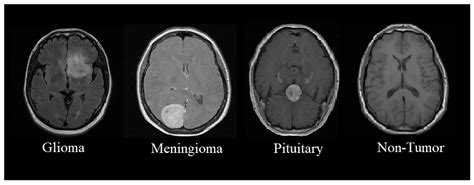

### AUROC for each segmentation model

TODO: check the following documentation: https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html

### Testing a new approach with negative samples

In [ ]:
def create_subsets_for_segmentation_with_negative_class(mask_path, images_path, negative_images_path, verbose=0):
  print_first=False
  # Load positive class (same as create_subsets_for_segmentation)
  X_train_pos, X_test_pos, Y_train_pos, Y_test_pos = create_subsets_for_segmentation(mask_path, images_path, verbose)

  # Load negative class images
  xt_images_neg = glob.glob(negative_images_path + "*.png")
  if(len(xt_images_neg)==0):
    xt_images_neg = glob.glob(negative_images_path + "*.PNG")
  if(len(xt_images_neg)==0):
    xt_images_neg = glob.glob(negative_images_path + "*.jpg")
  if(len(xt_images_neg)==0):
    xt_images_neg = glob.glob(negative_images_path + "*.jpeg")
  xt_images_neg.sort()
  x_t_neg = []
  if verbose == 1:
    print_first=True
  for img in xt_images_neg:
    # ignore images duplicated during upload to drive
    if "(" in img and ")" in img:
      pass
    else:
      image = cv2.imread(img, cv2.IMREAD_GRAYSCALE)
      image = image / 255
      image = trans.resize(image,(256,256))
      x_t_neg.append(image)
      if print_first == True:
        plt.imshow(image, cmap='gray')
        plt.show()
        print_first = False
  x_t_neg = np.array(x_t_neg)
  x_t_neg = np.reshape(x_t_neg, (len(x_t_neg), 256, 256, 1))

  # Create negative class masks (all zeros)
  Y_train_neg = np.zeros_like(Y_train_pos)
  Y_test_neg = np.zeros_like(x_t_neg) #Changed like y_test_pos to x_t_neg to maintain the same dimension of x_t_neg

  # Concatenate positive and negative classes
  X_train = np.concatenate([X_train_pos, x_t_neg]) #changed x_train_neg to x_t_neg
  X_test = np.concatenate([X_test_pos, x_t_neg]) #changed x_test_neg to x_t_neg
  Y_train = np.concatenate([Y_train_pos, Y_train_neg])
  Y_test = np.concatenate([Y_test_pos, Y_test_neg]) #changed y_test_neg to Y_test_neg

  return X_train, X_test, Y_train, Y_test

time: 1.17 ms (started: 2025-01-05 18:09:37 +00:00)


(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
8/8 [==============================] - 29s 4s/step


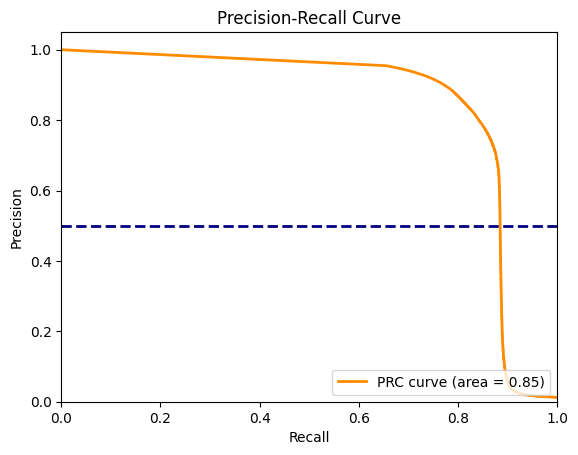

time: 42.2 s (started: 2025-01-05 18:09:55 +00:00)


In [ ]:
# Example usage
mask_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/glioma/masks/'
images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/glioma/images/'
negative_images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/thyroid/images/'


X_train, X_test, Y_train, Y_test = create_subsets_for_segmentation_with_negative_class(mask_path, images_path, negative_images_path)

# print(X_train.shape)
# print(X_test.shape)
# print(Y_train.shape)
# print(Y_test.shape)

# Now you can use X_test and Y_test in your plot_roc_curves_from_auc method

# PRC

# 1. Predict probabilities for the test set
y_pred_prob = segmentation_glioma.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute PRC curve and AUC
precision, recall, thresholds = precision_recall_curve(y_true_flat, y_pred_flat)
prc_auc = auc(recall, precision)  # Note: auc expects recall first, then precision

# 4. Plot the PRC
plt.figure()
plt.plot(recall, precision, color='darkorange', lw=2, label='PRC curve (area = %0.2f)' % prc_auc)
plt.plot([0, 1], [0.5, 0.5], color='navy', lw=2, linestyle='--')  # Baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower right")
plt.show()

# precisions.append(precision)
# recalls.append(recall)
# prc_aucs.append(prc_auc)
# model_names.append('Meningioma')



8/8 [==============================] - 18s 2s/step


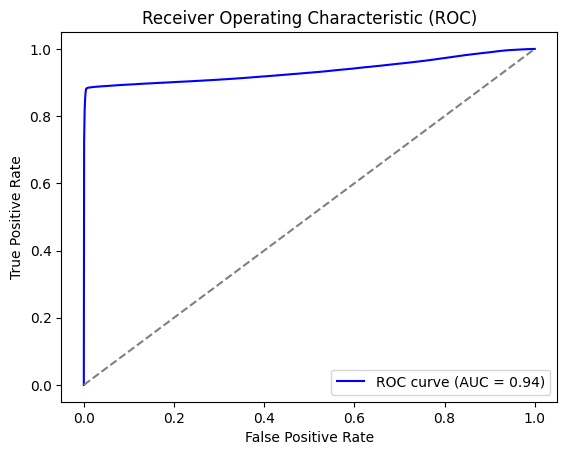

time: 23.1 s (started: 2025-01-05 18:10:38 +00:00)


In [ ]:
# AUC

# 1. Predict probabilities for the test set
y_pred_prob = segmentation_glioma.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_flat, y_pred_flat)
roc_auc = auc(fpr, tpr)

# 4. Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# fprs.append(fpr)
# tprs.append(tpr)
# roc_aucs.append(roc_auc)
# model_names.append('Glioma')

### PRC and AUC ROC curve - NEW

#### helper methods

In [ ]:
def create_subsets_for_segmentation_with_negative_class(mask_path, images_path, negative_images_path, verbose=0):
  print_first=False
  # Load positive class (same as create_subsets_for_segmentation)
  X_train_pos, X_test_pos, Y_train_pos, Y_test_pos = create_subsets_for_segmentation(mask_path, images_path, verbose)

  # Load negative class images
  xt_images_neg = glob.glob(negative_images_path + "*.png")
  if(len(xt_images_neg)==0):
    xt_images_neg = glob.glob(negative_images_path + "*.PNG")
  if(len(xt_images_neg)==0):
    xt_images_neg = glob.glob(negative_images_path + "*.jpg")
  if(len(xt_images_neg)==0):
    xt_images_neg = glob.glob(negative_images_path + "*.jpeg")
  xt_images_neg.sort()
  x_t_neg = []
  if verbose == 1:
    print_first=True
  for img in xt_images_neg:
    # ignore images duplicated during upload to drive
    if "(" in img and ")" in img:
      pass
    else:
      image = cv2.imread(img, cv2.IMREAD_GRAYSCALE)
      image = image / 255
      image = trans.resize(image,(256,256))
      x_t_neg.append(image)
      if print_first == True:
        plt.imshow(image, cmap='gray')
        plt.show()
        print_first = False
  x_t_neg = np.array(x_t_neg)
  x_t_neg = np.reshape(x_t_neg, (len(x_t_neg), 256, 256, 1))

  # Create negative class masks (all zeros)
  Y_train_neg = np.zeros_like(Y_train_pos)
  Y_test_neg = np.zeros_like(x_t_neg) #Changed like y_test_pos to x_t_neg to maintain the same dimension of x_t_neg

  # Concatenate positive and negative classes
  X_train = np.concatenate([X_train_pos, x_t_neg]) #changed x_train_neg to x_t_neg
  X_test = np.concatenate([X_test_pos, x_t_neg]) #changed x_test_neg to x_t_neg
  Y_train = np.concatenate([Y_train_pos, Y_train_neg])
  Y_test = np.concatenate([Y_test_pos, Y_test_neg]) #changed y_test_neg to Y_test_neg

  return X_train, X_test, Y_train, Y_test

time: 1.01 ms (started: 2025-01-05 18:13:52 +00:00)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics

precisions = []
recalls = []
prc_aucs = []
model_names = []
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple', 'tab:olive', 'tab:cyan', 'tab:pink', 'tab:red']

def plot_roc_curves_from_prc(prc_values, model_names):
    """Plots multiple ROC curves based on AUC values.

    Args:
        auc_values (list or numpy array): A list or array of AUC values for each model.
        model_names (list): A list of model names corresponding to the AUC values.
    """

    plt.figure(0).clf()

    # Assuming you have the FPR, TPR, and thresholds data for each AUC
    # If not, you'll need to generate them from your model predictions

    for i in range(0,len(prc_values)):
        prc_auc = auc(recalls[i], precisions[i])
        plt.plot(recalls[i], precisions[i], color=colors[i], lw=2, label=f"{model_names[i]}, PRC={prc_auc:.2f}")

    # Add labels and legend
    plt.plot([0, 1], [0.5, 0.5], color='navy', lw=2, linestyle='--')  # Baseline
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower right")

    # Show the plot
    plt.show()

time: 1.13 ms (started: 2025-01-05 18:13:54 +00:00)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics

fprs = []
tprs = []
roc_aucs = []
model_names = []
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple', 'tab:olive', 'tab:cyan', 'tab:pink', 'tab:red']

def plot_roc_curves_from_auc(auc_values, model_names):
    """Plots multiple ROC curves based on AUC values.

    Args:
        auc_values (list or numpy array): A list or array of AUC values for each model.
        model_names (list): A list of model names corresponding to the AUC values.
    """

    plt.figure(0).clf()

    # Assuming you have the FPR, TPR, and thresholds data for each AUC
    # If not, you'll need to generate them from your model predictions

    for i in range(0,len(auc_values)):
        roc_auc = auc(fprs[i], tprs[i])
        plt.plot(fprs[i], tprs[i], color=colors[i], label=f"{model_names[i]}, AUC={roc_auc:.2f}")

    # Add labels and legend
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves")
    plt.legend(loc="lower right")

    # Show the plot
    plt.show()

time: 909 µs (started: 2025-01-05 18:13:56 +00:00)


#### PRC ROC curve

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
8/8 [==============================] - 19s 2s/step


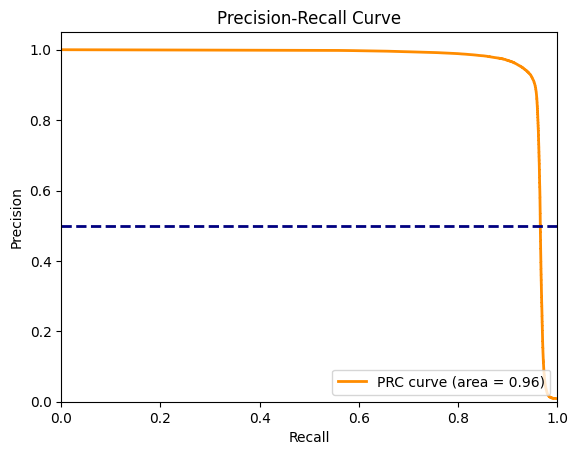

time: 30.6 s (started: 2025-01-05 18:14:48 +00:00)


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

mask_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/meningioma/masks/'
images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/meningioma/images/'
negative_images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/thyroid/images/'

X_train, X_test, Y_train, Y_test = create_subsets_for_segmentation_with_negative_class(mask_path, images_path, negative_images_path)

# 1. Predict probabilities for the test set
y_pred_prob = segmentation_meningioma.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute PRC curve and AUC
precision, recall, thresholds = precision_recall_curve(y_true_flat, y_pred_flat)
prc_auc = auc(recall, precision)  # Note: auc expects recall first, then precision

# 4. Plot the PRC
plt.figure()
plt.plot(recall, precision, color='darkorange', lw=2, label='PRC curve (area = %0.2f)' % prc_auc)
plt.plot([0, 1], [0.5, 0.5], color='navy', lw=2, linestyle='--')  # Baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower right")
plt.show()

precisions.append(precision)
recalls.append(recall)
prc_aucs.append(prc_auc)
model_names.append('Meningioma')

# plot_roc_curves_from_prc(prc_aucs, model_names)

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
8/8 [==============================] - 19s 2s/step


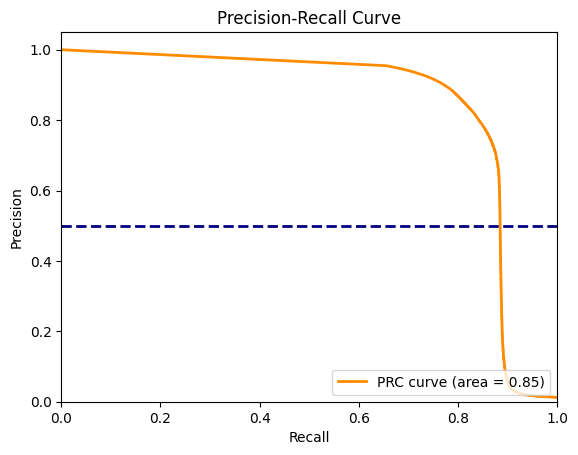

time: 29.9 s (started: 2025-01-05 18:15:19 +00:00)


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

mask_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/glioma/masks/'
images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/glioma/images/'
negative_images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/thyroid/images/'

X_train, X_test, Y_train, Y_test = create_subsets_for_segmentation_with_negative_class(mask_path, images_path, negative_images_path)


# 1. Predict probabilities for the test set
y_pred_prob = segmentation_glioma.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute PRC curve and AUC
precision, recall, thresholds = precision_recall_curve(y_true_flat, y_pred_flat)
prc_auc = auc(recall, precision)  # Note: auc expects recall first, then precision

# 4. Plot the PRC
plt.figure()
plt.plot(recall, precision, color='darkorange', lw=2, label='PRC curve (area = %0.2f)' % prc_auc)
plt.plot([0, 1], [0.5, 0.5], color='navy', lw=2, linestyle='--')  # Baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower right")
plt.show()

precisions.append(precision)
recalls.append(recall)
prc_aucs.append(prc_auc)
model_names.append('Glioma')

# plot_roc_curves_from_prc(prc_aucs, model_names)

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
8/8 [==============================] - 19s 2s/step


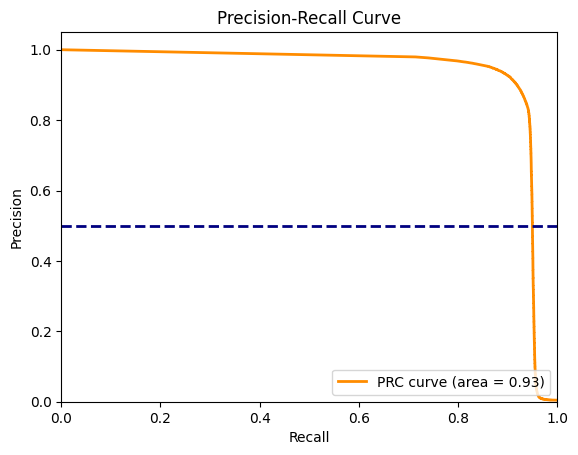

time: 30.1 s (started: 2025-01-05 18:15:49 +00:00)


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

mask_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/pituitary/masks/'
images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/pituitary/images/'
negative_images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/thyroid/images/'

X_train, X_test, Y_train, Y_test = create_subsets_for_segmentation_with_negative_class(mask_path, images_path, negative_images_path)


# 1. Predict probabilities for the test set
y_pred_prob = segmentation_pituitary.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute PRC curve and AUC
precision, recall, thresholds = precision_recall_curve(y_true_flat, y_pred_flat)
prc_auc = auc(recall, precision)  # Note: auc expects recall first, then precision

# 4. Plot the PRC
plt.figure()
plt.plot(recall, precision, color='darkorange', lw=2, label='PRC curve (area = %0.2f)' % prc_auc)
plt.plot([0, 1], [0.5, 0.5], color='navy', lw=2, linestyle='--')  # Baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower right")
plt.show()

precisions.append(precision)
recalls.append(recall)
prc_aucs.append(prc_auc)
model_names.append('Pituitary')

# plot_roc_curves_from_prc(prc_aucs, model_names)

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
8/8 [==============================] - 19s 2s/step


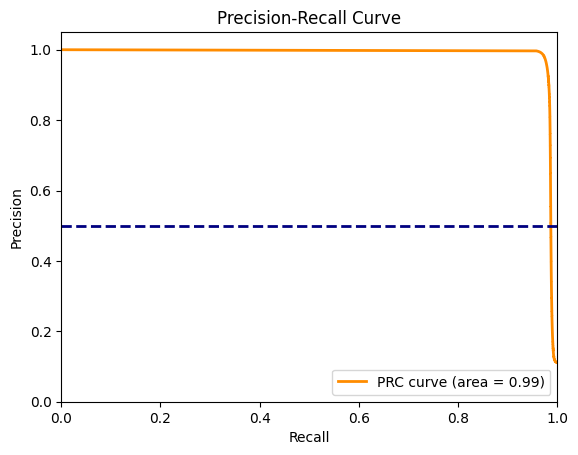

time: 28.3 s (started: 2025-01-05 18:16:19 +00:00)


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

mask_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/covid/masks/'
images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/covid/images/'
negative_images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/thyroid/images/'

X_train, X_test, Y_train, Y_test = create_subsets_for_segmentation_with_negative_class(mask_path, images_path, negative_images_path)


# 1. Predict probabilities for the test set
y_pred_prob = segmentation_covid.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute PRC curve and AUC
precision, recall, thresholds = precision_recall_curve(y_true_flat, y_pred_flat)
prc_auc = auc(recall, precision)  # Note: auc expects recall first, then precision

# 4. Plot the PRC
plt.figure()
plt.plot(recall, precision, color='darkorange', lw=2, label='PRC curve (area = %0.2f)' % prc_auc)
plt.plot([0, 1], [0.5, 0.5], color='navy', lw=2, linestyle='--')  # Baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower right")
plt.show()

precisions.append(precision)
recalls.append(recall)
prc_aucs.append(prc_auc)
model_names.append('COVID-19')

# plot_roc_curves_from_prc(prc_aucs, model_names)

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
8/8 [==============================] - 19s 2s/step


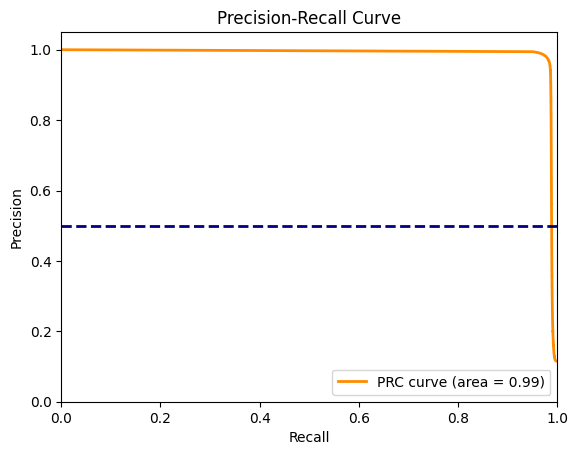

time: 28.5 s (started: 2025-01-05 18:16:47 +00:00)


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

mask_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/pneumonia/masks/'
images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/pneumonia/images/'
negative_images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/thyroid/images/'

X_train, X_test, Y_train, Y_test = create_subsets_for_segmentation_with_negative_class(mask_path, images_path, negative_images_path)


# 1. Predict probabilities for the test set
y_pred_prob = segmentation_pneumonia.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute PRC curve and AUC
precision, recall, thresholds = precision_recall_curve(y_true_flat, y_pred_flat)
prc_auc = auc(recall, precision)  # Note: auc expects recall first, then precision

# 4. Plot the PRC
plt.figure()
plt.plot(recall, precision, color='darkorange', lw=2, label='PRC curve (area = %0.2f)' % prc_auc)
plt.plot([0, 1], [0.5, 0.5], color='navy', lw=2, linestyle='--')  # Baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower right")
plt.show()

precisions.append(precision)
recalls.append(recall)
prc_aucs.append(prc_auc)
model_names.append('Pneumonia')

# plot_roc_curves_from_prc(prc_aucs, model_names)

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
(127, 256, 256, 1)
(248, 256, 256, 1)
(4, 256, 256, 1)
(248, 256, 256, 1)
8/8 [==============================] - 18s 2s/step


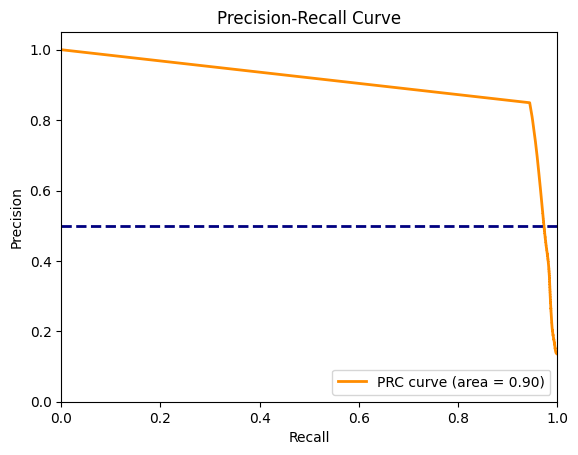

time: 25.9 s (started: 2025-01-05 18:21:04 +00:00)


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

mask_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/normal-lung/masks/'
images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/normal-lung/images/'
negative_images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/thyroid/images/'

X_train, X_test, Y_train, Y_test = create_subsets_for_segmentation_with_negative_class(mask_path, images_path, negative_images_path)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

# 1. Predict probabilities for the test set
y_pred_prob = segmentation_normal_lung.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute PRC curve and AUC
precision, recall, thresholds = precision_recall_curve(y_true_flat, y_pred_flat)
prc_auc = auc(recall, precision)  # Note: auc expects recall first, then precision

# 4. Plot the PRC
plt.figure()
plt.plot(recall, precision, color='darkorange', lw=2, label='PRC curve (area = %0.2f)' % prc_auc)
plt.plot([0, 1], [0.5, 0.5], color='navy', lw=2, linestyle='--')  # Baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower right")
plt.show()

# precisions.append(precision)
# recalls.append(recall)
# prc_aucs.append(prc_auc)
# model_names.append('Non-lesion lung')

# plot_roc_curves_from_prc(prc_aucs, model_names)

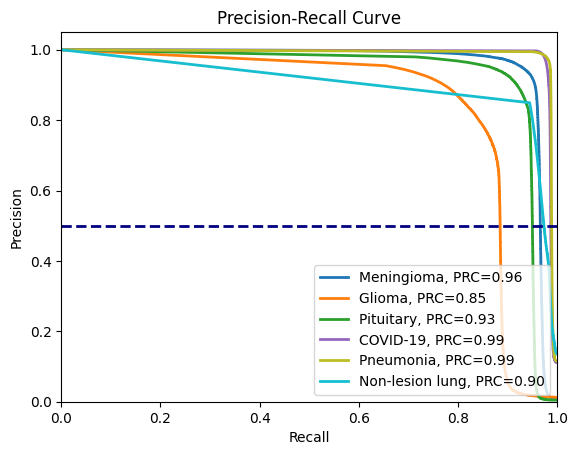

time: 3.79 s (started: 2025-01-05 18:17:45 +00:00)


In [ ]:
plot_roc_curves_from_prc(prc_aucs, model_names)

#### AUC ROC curve

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
8/8 [==============================] - 18s 2s/step


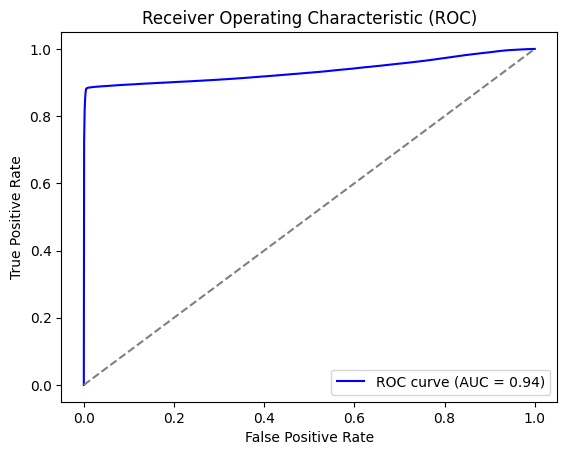

time: 29.6 s (started: 2025-01-05 18:17:49 +00:00)


In [ ]:
# e.g.

import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

mask_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/glioma/masks/'
images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/glioma/images/'
negative_images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/thyroid/images/'

X_train, X_test, Y_train, Y_test = create_subsets_for_segmentation_with_negative_class(mask_path, images_path, negative_images_path)



# 1. Predict probabilities for the test set
y_pred_prob = segmentation_glioma.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_flat, y_pred_flat)
roc_auc = auc(fpr, tpr)

# 4. Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

fprs.append(fpr)
tprs.append(tpr)
roc_aucs.append(roc_auc)
model_names.append('Glioma')

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
8/8 [==============================] - 22s 3s/step


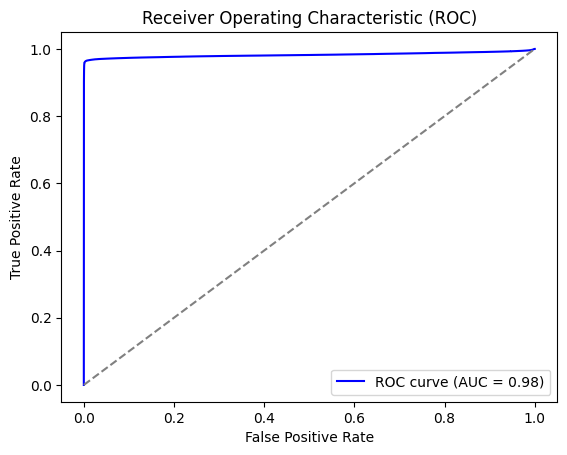

time: 33.9 s (started: 2025-01-05 18:18:18 +00:00)


In [ ]:
# e.g.

import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


mask_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/meningioma/masks/'
images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/meningioma/images/'
negative_images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/thyroid/images/'

X_train, X_test, Y_train, Y_test = create_subsets_for_segmentation_with_negative_class(mask_path, images_path, negative_images_path)


# 1. Predict probabilities for the test set
y_pred_prob = segmentation_meningioma.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_flat, y_pred_flat)
roc_auc = auc(fpr, tpr)

# 4. Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

fprs.append(fpr)
tprs.append(tpr)
roc_aucs.append(roc_auc)
model_names.append('Meningioma')

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
8/8 [==============================] - 17s 2s/step


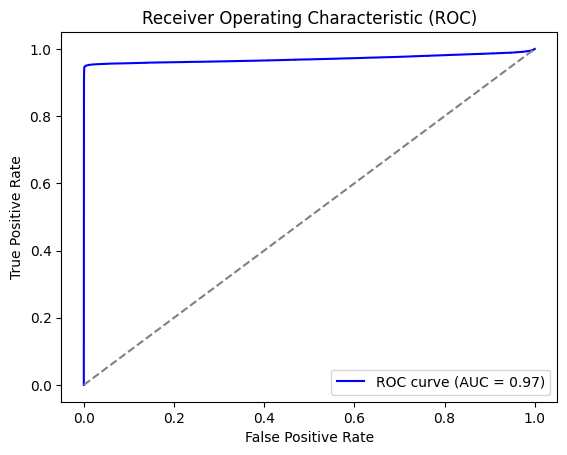

time: 28.1 s (started: 2025-01-05 18:18:52 +00:00)


In [ ]:
# e.g.

import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

mask_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/pituitary/masks/'
images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/pituitary/images/'
negative_images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/thyroid/images/'

X_train, X_test, Y_train, Y_test = create_subsets_for_segmentation_with_negative_class(mask_path, images_path, negative_images_path)


# 1. Predict probabilities for the test set
y_pred_prob = segmentation_pituitary.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_flat, y_pred_flat)
roc_auc = auc(fpr, tpr)

# 4. Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

fprs.append(fpr)
tprs.append(tpr)
roc_aucs.append(roc_auc)
model_names.append('Pituitary')

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
8/8 [==============================] - 18s 2s/step


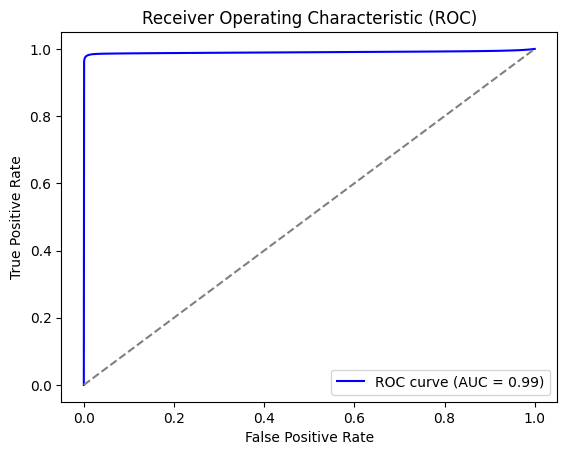

time: 26.9 s (started: 2025-01-05 18:19:20 +00:00)


In [ ]:
# e.g.

import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

mask_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/covid/masks/'
images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/covid/images/'
negative_images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/thyroid/images/'

X_train, X_test, Y_train, Y_test = create_subsets_for_segmentation_with_negative_class(mask_path, images_path, negative_images_path)

# 1. Predict probabilities for the test set
y_pred_prob = segmentation_covid.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_flat, y_pred_flat)
roc_auc = auc(fpr, tpr)

# 4. Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

fprs.append(fpr)
tprs.append(tpr)
roc_aucs.append(roc_auc)
model_names.append('COVID-19')

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
8/8 [==============================] - 17s 2s/step


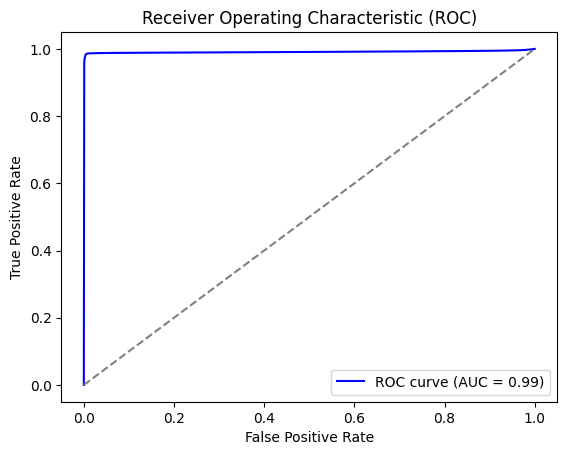

time: 26.5 s (started: 2025-01-05 18:19:47 +00:00)


In [ ]:
# e.g.

import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


mask_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/pneumonia/masks/'
images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/pneumonia/images/'
negative_images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/thyroid/images/'

X_train, X_test, Y_train, Y_test = create_subsets_for_segmentation_with_negative_class(mask_path, images_path, negative_images_path)

# 1. Predict probabilities for the test set
y_pred_prob = segmentation_pneumonia.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_flat, y_pred_flat)
roc_auc = auc(fpr, tpr)

# 4. Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

fprs.append(fpr)
tprs.append(tpr)
roc_aucs.append(roc_auc)
model_names.append('Pneumonia')

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
8/8 [==============================] - 17s 2s/step


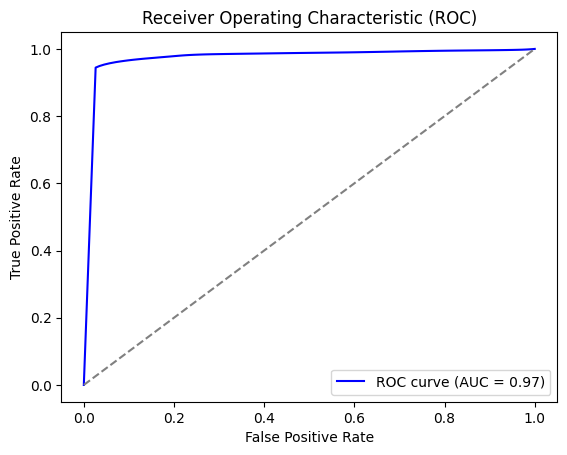

time: 24.6 s (started: 2025-01-05 18:20:14 +00:00)


In [ ]:
# e.g.

import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

mask_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/normal-lung/masks/'
images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/normal-lung/images/'
negative_images_path = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/thyroid/images/'

X_train, X_test, Y_train, Y_test = create_subsets_for_segmentation_with_negative_class(mask_path, images_path, negative_images_path)

# 1. Predict probabilities for the test set
y_pred_prob = segmentation_normal_lung.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_flat, y_pred_flat)
roc_auc = auc(fpr, tpr)

# 4. Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

fprs.append(fpr)
tprs.append(tpr)
roc_aucs.append(roc_auc)
model_names.append('Non-lesion lung')

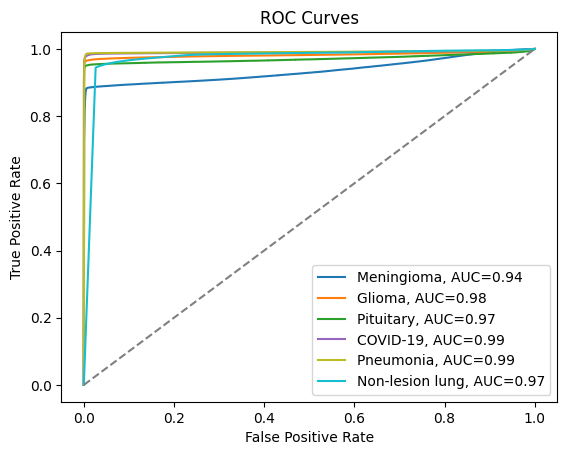

time: 2.72 s (started: 2025-01-05 18:20:38 +00:00)


In [ ]:
plot_roc_curves_from_auc(roc_aucs, model_names)

### PRC and AUC ROC curve

#### helper methods

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics

precisions = []
recalls = []
prc_aucs = []
model_names = []
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple', 'tab:olive', 'tab:cyan', 'tab:pink', 'tab:red']

def plot_roc_curves_from_prc(prc_values, model_names):
    """Plots multiple ROC curves based on AUC values.

    Args:
        auc_values (list or numpy array): A list or array of AUC values for each model.
        model_names (list): A list of model names corresponding to the AUC values.
    """

    plt.figure(0).clf()

    # Assuming you have the FPR, TPR, and thresholds data for each AUC
    # If not, you'll need to generate them from your model predictions

    for i in range(0,len(prc_values)):
        prc_auc = auc(recalls[i], precisions[i])
        plt.plot(recalls[i], precisions[i], color=colors[i], lw=2, label=f"{model_names[i]}, PRC={prc_auc:.2f}")

    # Add labels and legend
    plt.plot([0, 1], [0.5, 0.5], color='navy', lw=2, linestyle='--')  # Baseline
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower right")

    # Show the plot
    plt.show()

time: 822 µs (started: 2025-01-05 17:58:45 +00:00)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics

fprs = []
tprs = []
roc_aucs = []
model_names = []
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple', 'tab:olive', 'tab:cyan', 'tab:pink', 'tab:red']

def plot_roc_curves_from_auc(auc_values, model_names):
    """Plots multiple ROC curves based on AUC values.

    Args:
        auc_values (list or numpy array): A list or array of AUC values for each model.
        model_names (list): A list of model names corresponding to the AUC values.
    """

    plt.figure(0).clf()

    # Assuming you have the FPR, TPR, and thresholds data for each AUC
    # If not, you'll need to generate them from your model predictions

    for i in range(0,len(auc_values)):
        roc_auc = auc(fprs[i], tprs[i])
        plt.plot(fprs[i], tprs[i], color=colors[i], label=f"{model_names[i]}, AUC={roc_auc:.2f}")

    # Add labels and legend
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves")
    plt.legend(loc="lower right")

    # Show the plot
    plt.show()

time: 780 µs (started: 2025-01-05 17:58:45 +00:00)


#### PRC ROC curve

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
4/4 [==============================] - 8s 2s/step


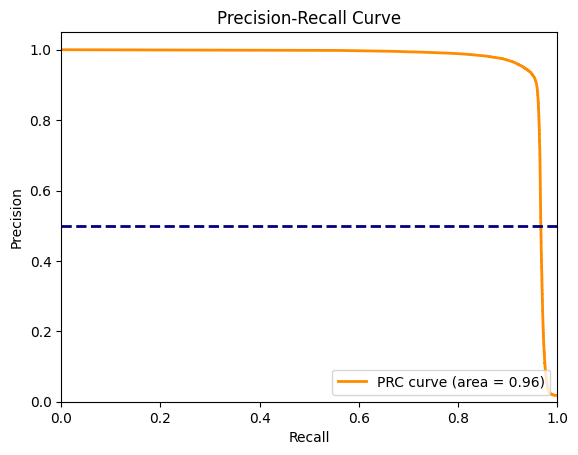

time: 14.8 s (started: 2025-01-05 17:58:45 +00:00)


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# Assuming you have test data and true masks in `X_test` and `y_test`, and the model is `unet_model`
dataset_validation = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/meningioma/'
base_path = dataset_validation
xt_path = base_path + "images/"
xa_path = base_path + "masks/"

X_train , X_test, Y_train, Y_test = create_subsets_for_segmentation(xa_path, xt_path)

# 1. Predict probabilities for the test set
y_pred_prob = segmentation_meningioma.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute PRC curve and AUC
precision, recall, thresholds = precision_recall_curve(y_true_flat, y_pred_flat)
prc_auc = auc(recall, precision)  # Note: auc expects recall first, then precision

# 4. Plot the PRC
plt.figure()
plt.plot(recall, precision, color='darkorange', lw=2, label='PRC curve (area = %0.2f)' % prc_auc)
plt.plot([0, 1], [0.5, 0.5], color='navy', lw=2, linestyle='--')  # Baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower right")
plt.show()

precisions.append(precision)
recalls.append(recall)
prc_aucs.append(prc_auc)
model_names.append('Meningioma')

# plot_roc_curves_from_prc(prc_aucs, model_names)

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
4/4 [==============================] - 15s 4s/step


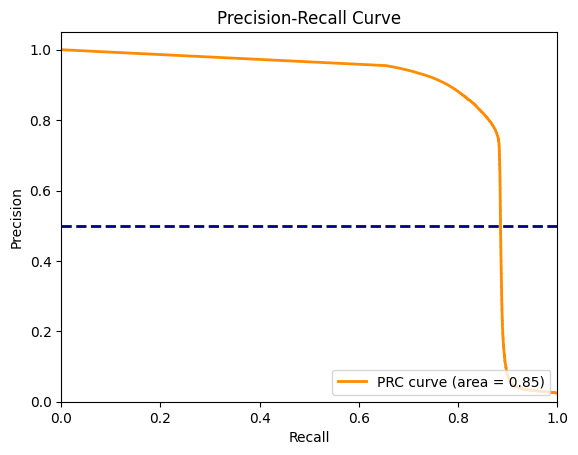

time: 23.3 s (started: 2025-01-05 17:59:00 +00:00)


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# Assuming you have test data and true masks in `X_test` and `y_test`, and the model is `unet_model`
dataset_validation = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/glioma/'
base_path = dataset_validation
xt_path = base_path + "images/"
xa_path = base_path + "masks/"

X_train , X_test, Y_train, Y_test = create_subsets_for_segmentation(xa_path, xt_path)

# 1. Predict probabilities for the test set
y_pred_prob = segmentation_glioma.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute PRC curve and AUC
precision, recall, thresholds = precision_recall_curve(y_true_flat, y_pred_flat)
prc_auc = auc(recall, precision)  # Note: auc expects recall first, then precision

# 4. Plot the PRC
plt.figure()
plt.plot(recall, precision, color='darkorange', lw=2, label='PRC curve (area = %0.2f)' % prc_auc)
plt.plot([0, 1], [0.5, 0.5], color='navy', lw=2, linestyle='--')  # Baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower right")
plt.show()

precisions.append(precision)
recalls.append(recall)
prc_aucs.append(prc_auc)
model_names.append('Glioma')

# plot_roc_curves_from_prc(prc_aucs, model_names)

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
4/4 [==============================] - 14s 4s/step


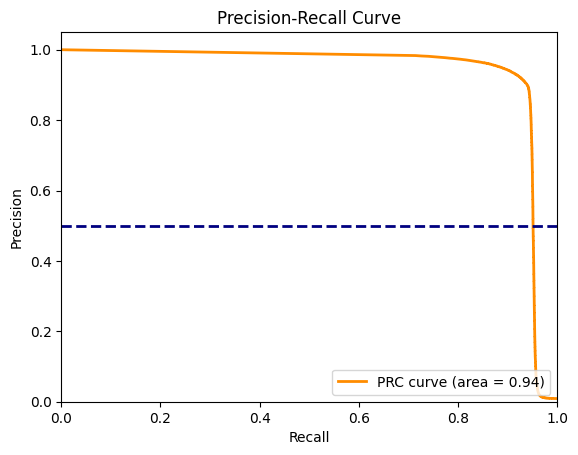

time: 21.1 s (started: 2025-01-05 17:59:23 +00:00)


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# Assuming you have test data and true masks in `X_test` and `y_test`, and the model is `unet_model`
dataset_validation = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/pituitary/'
base_path = dataset_validation
xt_path = base_path + "images/"
xa_path = base_path + "masks/"

X_train , X_test, Y_train, Y_test = create_subsets_for_segmentation(xa_path, xt_path)

# 1. Predict probabilities for the test set
y_pred_prob = segmentation_pituitary.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute PRC curve and AUC
precision, recall, thresholds = precision_recall_curve(y_true_flat, y_pred_flat)
prc_auc = auc(recall, precision)  # Note: auc expects recall first, then precision

# 4. Plot the PRC
plt.figure()
plt.plot(recall, precision, color='darkorange', lw=2, label='PRC curve (area = %0.2f)' % prc_auc)
plt.plot([0, 1], [0.5, 0.5], color='navy', lw=2, linestyle='--')  # Baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower right")
plt.show()

precisions.append(precision)
recalls.append(recall)
prc_aucs.append(prc_auc)
model_names.append('Pituitary')

# plot_roc_curves_from_prc(prc_aucs, model_names)

In [ ]:
# # e.g.

# import numpy as np
# from sklearn.metrics import roc_curve, auc, precision_recall_curve
# import matplotlib.pyplot as plt

# # Assuming you have test data and true masks in `X_test` and `y_test`, and the model is `unet_model`
# dataset_validation = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/thyroid/'
# base_path = dataset_validation
# xt_path = base_path + "images/"
# xa_path = base_path + "masks/"

# X_train , X_test, Y_train, Y_test = create_subsets_for_segmentation(xa_path, xt_path)

# # 1. Predict probabilities for the test set
# y_pred_prob = segmentation_thyroid.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# # 2. Flatten the arrays
# y_pred_flat = y_pred_prob.flatten()
# y_true_flat = Y_test.flatten()

# # 3. Compute ROC curve and AUC
# # fpr, tpr, thresholds = roc_curve(y_true_flat, y_pred_flat)
# # roc_auc = auc(fpr, tpr)

# # 3. Compute PRC curve and AUC
# precision, recall, thresholds = precision_recall_curve(y_true_flat, y_pred_flat)
# prc_auc = auc(recall, precision)  # Note: auc expects recall first, then precision


# # 4. Plot the PRC
# plt.figure()
# plt.plot(recall, precision, color='darkorange', lw=2, label='PRC curve (area = %0.2f)' % prc_auc)
# plt.plot([0, 1], [0.5, 0.5], color='navy', lw=2, linestyle='--')  # Baseline
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve')
# plt.legend(loc="lower right")
# plt.show()

# precisions.append(precision)
# recalls.append(recall)
# prc_aucs.append(prc_auc)
# model_names.append('thyroid')

# # plot_roc_curves_from_prc(prc_aucs, model_names)

time: 236 µs (started: 2025-01-05 17:59:44 +00:00)


(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
4/4 [==============================] - 9s 2s/step


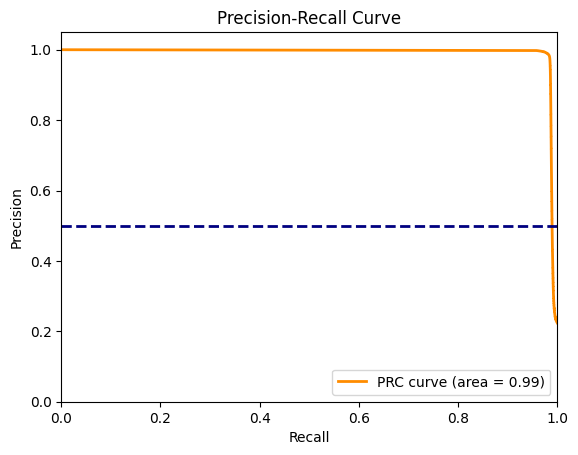

time: 13 s (started: 2025-01-05 17:59:44 +00:00)


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# Assuming you have test data and true masks in `X_test` and `y_test`, and the model is `unet_model`
dataset_validation = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/covid/'
base_path = dataset_validation
xt_path = base_path + "images/"
xa_path = base_path + "masks/"

X_train , X_test, Y_train, Y_test = create_subsets_for_segmentation(xa_path, xt_path)

# 1. Predict probabilities for the test set
y_pred_prob = segmentation_covid.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute PRC curve and AUC
precision, recall, thresholds = precision_recall_curve(y_true_flat, y_pred_flat)
prc_auc = auc(recall, precision)  # Note: auc expects recall first, then precision

# 4. Plot the PRC
plt.figure()
plt.plot(recall, precision, color='darkorange', lw=2, label='PRC curve (area = %0.2f)' % prc_auc)
plt.plot([0, 1], [0.5, 0.5], color='navy', lw=2, linestyle='--')  # Baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower right")
plt.show()

precisions.append(precision)
recalls.append(recall)
prc_aucs.append(prc_auc)
model_names.append('COVID-19')

# plot_roc_curves_from_prc(prc_aucs, model_names)

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
4/4 [==============================] - 9s 2s/step


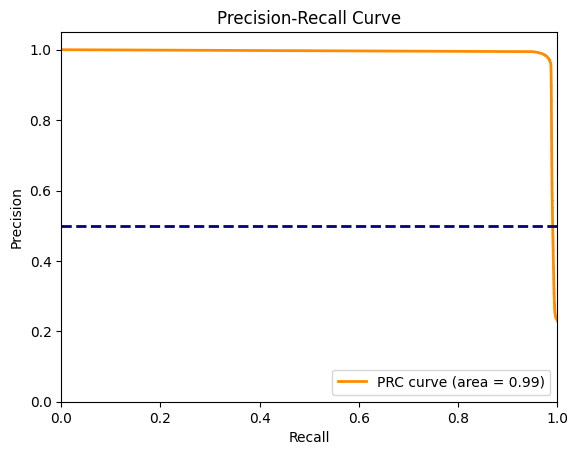

time: 12.7 s (started: 2025-01-05 17:59:57 +00:00)


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# Assuming you have test data and true masks in `X_test` and `y_test`, and the model is `unet_model`
dataset_validation = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/pneumonia/'
base_path = dataset_validation
xt_path = base_path + "images/"
xa_path = base_path + "masks/"

X_train , X_test, Y_train, Y_test = create_subsets_for_segmentation(xa_path, xt_path)

# 1. Predict probabilities for the test set
y_pred_prob = segmentation_pneumonia.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute PRC curve and AUC
precision, recall, thresholds = precision_recall_curve(y_true_flat, y_pred_flat)
prc_auc = auc(recall, precision)  # Note: auc expects recall first, then precision

# 4. Plot the PRC
plt.figure()
plt.plot(recall, precision, color='darkorange', lw=2, label='PRC curve (area = %0.2f)' % prc_auc)
plt.plot([0, 1], [0.5, 0.5], color='navy', lw=2, linestyle='--')  # Baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower right")
plt.show()

precisions.append(precision)
recalls.append(recall)
prc_aucs.append(prc_auc)
model_names.append('Pneumonia')

# plot_roc_curves_from_prc(prc_aucs, model_names)

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
4/4 [==============================] - 8s 2s/step


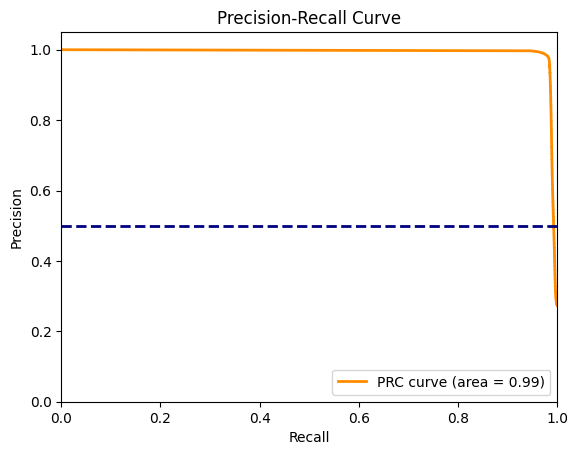

time: 12.5 s (started: 2025-01-05 18:00:10 +00:00)


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# Assuming you have test data and true masks in `X_test` and `y_test`, and the model is `unet_model`
dataset_validation = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/normal-lung/'
base_path = dataset_validation
xt_path = base_path + "images/"
xa_path = base_path + "masks/"

X_train , X_test, Y_train, Y_test = create_subsets_for_segmentation(xa_path, xt_path)

# 1. Predict probabilities for the test set
y_pred_prob = segmentation_normal_lung.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute PRC curve and AUC
precision, recall, thresholds = precision_recall_curve(y_true_flat, y_pred_flat)
prc_auc = auc(recall, precision)  # Note: auc expects recall first, then precision

# 4. Plot the PRC
plt.figure()
plt.plot(recall, precision, color='darkorange', lw=2, label='PRC curve (area = %0.2f)' % prc_auc)
plt.plot([0, 1], [0.5, 0.5], color='navy', lw=2, linestyle='--')  # Baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower right")
plt.show()

precisions.append(precision)
recalls.append(recall)
prc_aucs.append(prc_auc)
model_names.append('Non-lesion lung')

# plot_roc_curves_from_prc(prc_aucs, model_names)

In [ ]:
# import numpy as np
# from sklearn.metrics import roc_curve, auc, precision_recall_curve
# import matplotlib.pyplot as plt

# # Assuming you have test data and true masks in `X_test` and `y_test`, and the model is `unet_model`
# dataset_validation = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/cad/'
# base_path = dataset_validation
# xt_path = base_path + "images/"
# xa_path = base_path + "masks/"

# X_train , X_test, Y_train, Y_test = create_subsets_for_segmentation(xa_path, xt_path)

# # 1. Predict probabilities for the test set
# y_pred_prob = segmentation_cad.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# # 2. Flatten the arrays
# y_pred_flat = y_pred_prob.flatten()
# y_true_flat = Y_test.flatten()

# # 3. Compute PRC curve and AUC
# precision, recall, thresholds = precision_recall_curve(y_true_flat, y_pred_flat)
# prc_auc = auc(recall, precision)  # Note: auc expects recall first, then precision

# # 4. Plot the PRC
# plt.figure()
# plt.plot(recall, precision, color='darkorange', lw=2, label='PRC curve (area = %0.2f)' % prc_auc)
# plt.plot([0, 1], [0.5, 0.5], color='navy', lw=2, linestyle='--')  # Baseline
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve')
# plt.legend(loc="lower right")
# plt.show()

# precisions.append(precision)
# recalls.append(recall)
# prc_aucs.append(prc_auc)
# model_names.append('cad')

# # plot_roc_curves_from_prc(prc_aucs, model_names)

time: 249 µs (started: 2025-01-05 18:00:22 +00:00)


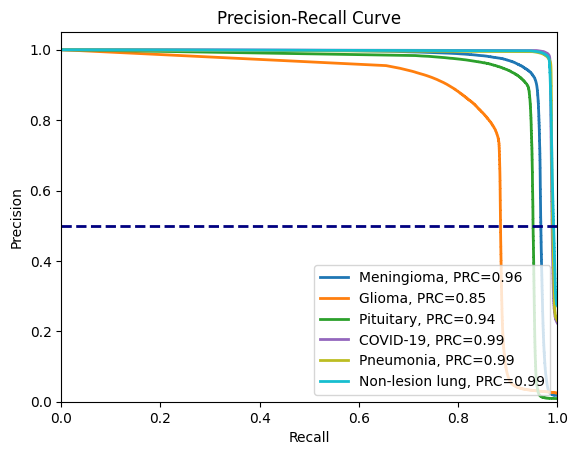

time: 2.41 s (started: 2025-01-05 18:00:22 +00:00)


In [ ]:
plot_roc_curves_from_prc(prc_aucs, model_names)

#### AUC ROC curve

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
4/4 [==============================] - 8s 2s/step


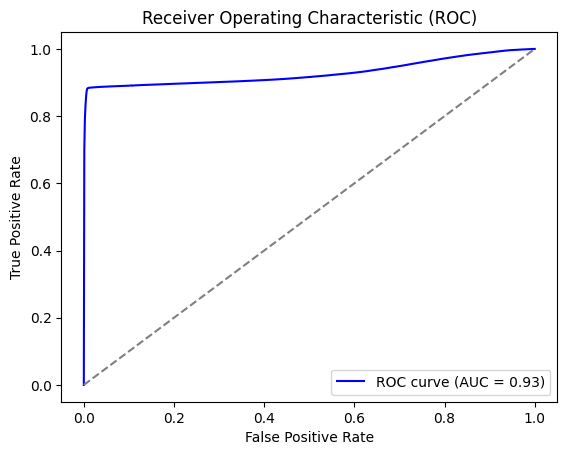

time: 13.9 s (started: 2025-01-05 17:57:24 +00:00)


In [ ]:
# e.g.

import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have test data and true masks in `X_test` and `y_test`, and the model is `unet_model`
dataset_validation = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/glioma/'
base_path = dataset_validation
xt_path = base_path + "images/"
xa_path = base_path + "masks/"

X_train , X_test, Y_train, Y_test = create_subsets_for_segmentation(xa_path, xt_path)

# 1. Predict probabilities for the test set
y_pred_prob = segmentation_glioma.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_flat, y_pred_flat)
roc_auc = auc(fpr, tpr)

# 4. Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

fprs.append(fpr)
tprs.append(tpr)
roc_aucs.append(roc_auc)
model_names.append('Glioma')

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
4/4 [==============================] - 8s 2s/step


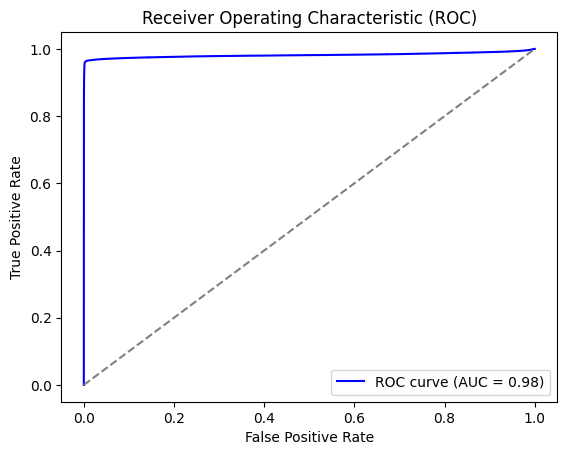

time: 13.9 s (started: 2025-01-05 17:57:38 +00:00)


In [ ]:
# e.g.

import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have test data and true masks in `X_test` and `y_test`, and the model is `unet_model`
dataset_validation = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/meningioma/'
base_path = dataset_validation
xt_path = base_path + "images/"
xa_path = base_path + "masks/"

X_train , X_test, Y_train, Y_test = create_subsets_for_segmentation(xa_path, xt_path)

# 1. Predict probabilities for the test set
y_pred_prob = segmentation_meningioma.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_flat, y_pred_flat)
roc_auc = auc(fpr, tpr)

# 4. Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

fprs.append(fpr)
tprs.append(tpr)
roc_aucs.append(roc_auc)
model_names.append('Meningioma')

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
4/4 [==============================] - 8s 2s/step


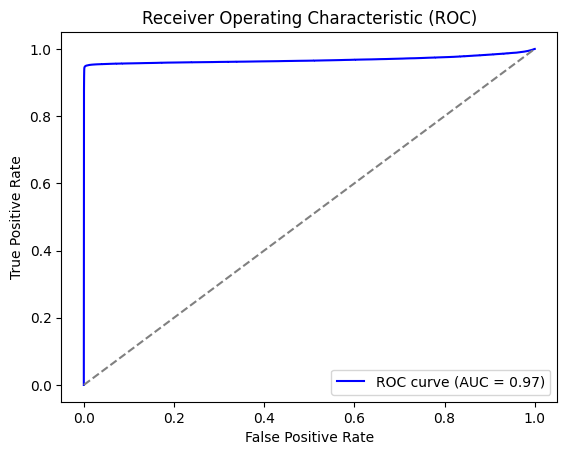

time: 14.4 s (started: 2025-01-05 17:57:52 +00:00)


In [ ]:
# e.g.

import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have test data and true masks in `X_test` and `y_test`, and the model is `unet_model`
dataset_validation = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/pituitary/'
base_path = dataset_validation
xt_path = base_path + "images/"
xa_path = base_path + "masks/"

X_train , X_test, Y_train, Y_test = create_subsets_for_segmentation(xa_path, xt_path)

# 1. Predict probabilities for the test set
y_pred_prob = segmentation_pituitary.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_flat, y_pred_flat)
roc_auc = auc(fpr, tpr)

# 4. Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

fprs.append(fpr)
tprs.append(tpr)
roc_aucs.append(roc_auc)
model_names.append('Pituitary')

In [ ]:
# # e.g.

# import numpy as np
# from sklearn.metrics import roc_curve, auc
# import matplotlib.pyplot as plt

# # Assuming you have test data and true masks in `X_test` and `y_test`, and the model is `unet_model`
# dataset_validation = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/thyroid/'
# base_path = dataset_validation
# xt_path = base_path + "images/"
# xa_path = base_path + "masks/"

# X_train , X_test, Y_train, Y_test = create_subsets_for_segmentation(xa_path, xt_path)

# # 1. Predict probabilities for the test set
# y_pred_prob = segmentation_thyroid.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# # 2. Flatten the arrays
# y_pred_flat = y_pred_prob.flatten()
# y_true_flat = Y_test.flatten()

# # 3. Compute ROC curve and AUC
# fpr, tpr, thresholds = roc_curve(y_true_flat, y_pred_flat)
# roc_auc = auc(fpr, tpr)

# # 4. Plot the ROC curve
# plt.figure()
# plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
# plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC)')
# plt.legend(loc="lower right")
# plt.show()

# fprs.append(fpr)
# tprs.append(tpr)
# roc_aucs.append(roc_auc)
# model_names.append('thyroid')

time: 311 µs (started: 2025-01-05 17:58:06 +00:00)


(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
4/4 [==============================] - 8s 2s/step


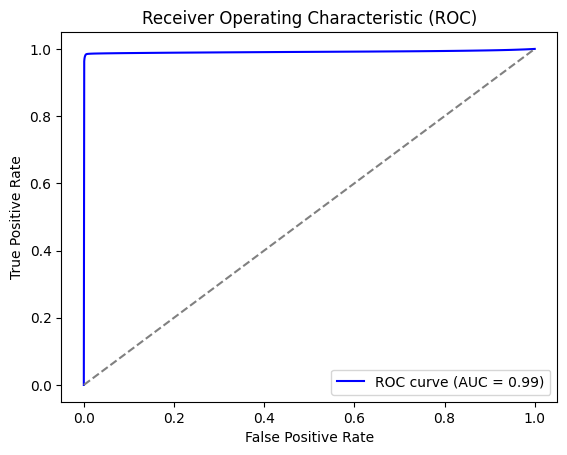

time: 12.8 s (started: 2025-01-05 17:58:06 +00:00)


In [ ]:
# e.g.

import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have test data and true masks in `X_test` and `y_test`, and the model is `unet_model`
dataset_validation = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/covid/'
base_path = dataset_validation
xt_path = base_path + "images/"
xa_path = base_path + "masks/"

X_train , X_test, Y_train, Y_test = create_subsets_for_segmentation(xa_path, xt_path)

# 1. Predict probabilities for the test set
y_pred_prob = segmentation_covid.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_flat, y_pred_flat)
roc_auc = auc(fpr, tpr)

# 4. Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

fprs.append(fpr)
tprs.append(tpr)
roc_aucs.append(roc_auc)
model_names.append('COVID-19')

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
4/4 [==============================] - 8s 2s/step


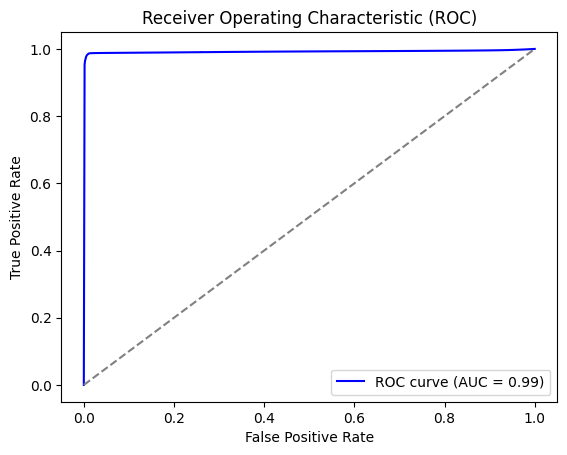

time: 12.2 s (started: 2025-01-05 17:58:19 +00:00)


In [ ]:
# e.g.

import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have test data and true masks in `X_test` and `y_test`, and the model is `unet_model`
dataset_validation = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/pneumonia/'
base_path = dataset_validation
xt_path = base_path + "images/"
xa_path = base_path + "masks/"

X_train , X_test, Y_train, Y_test = create_subsets_for_segmentation(xa_path, xt_path)

# 1. Predict probabilities for the test set
y_pred_prob = segmentation_pneumonia.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_flat, y_pred_flat)
roc_auc = auc(fpr, tpr)

# 4. Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

fprs.append(fpr)
tprs.append(tpr)
roc_aucs.append(roc_auc)
model_names.append('Pneumonia')

(2, 256, 256, 1)
(123, 256, 256, 1)
(2, 256, 256, 1)
(123, 256, 256, 1)
4/4 [==============================] - 8s 2s/step


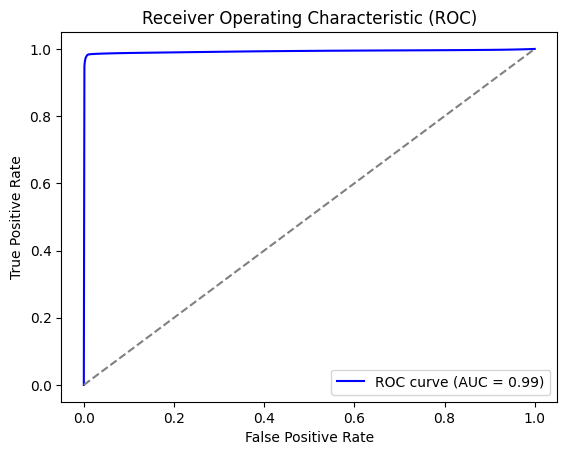

time: 12.7 s (started: 2025-01-05 17:58:31 +00:00)


In [ ]:
# e.g.

import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have test data and true masks in `X_test` and `y_test`, and the model is `unet_model`
dataset_validation = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/normal-lung/'
base_path = dataset_validation
xt_path = base_path + "images/"
xa_path = base_path + "masks/"

X_train , X_test, Y_train, Y_test = create_subsets_for_segmentation(xa_path, xt_path)

# 1. Predict probabilities for the test set
y_pred_prob = segmentation_normal_lung.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# 2. Flatten the arrays
y_pred_flat = y_pred_prob.flatten()
y_true_flat = Y_test.flatten()

# 3. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_flat, y_pred_flat)
roc_auc = auc(fpr, tpr)

# 4. Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

fprs.append(fpr)
tprs.append(tpr)
roc_aucs.append(roc_auc)
model_names.append('Non-lesion lung')

In [ ]:
# # e.g.

# import numpy as np
# from sklearn.metrics import roc_curve, auc
# import matplotlib.pyplot as plt

# # Assuming you have test data and true masks in `X_test` and `y_test`, and the model is `unet_model`
# dataset_validation = '/content/drive/MyDrive/Doutorado/Datasets/dataset-validation-segmentation/cad/'
# base_path = dataset_validation
# xt_path = base_path + "images/"
# xa_path = base_path + "masks/"

# X_train , X_test, Y_train, Y_test = create_subsets_for_segmentation(xa_path, xt_path)

# # 1. Predict probabilities for the test set
# y_pred_prob = segmentation_cad.predict(X_test)  # Shape should be (batch, height, width, 1) for binary segmentation

# # 2. Flatten the arrays
# y_pred_flat = y_pred_prob.flatten()
# y_true_flat = Y_test.flatten()

# # 3. Compute ROC curve and AUC
# fpr, tpr, thresholds = roc_curve(y_true_flat, y_pred_flat)
# roc_auc = auc(fpr, tpr)

# # 4. Plot the ROC curve
# plt.figure()
# plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
# plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC)')
# plt.legend(loc="lower right")
# plt.show()

# fprs.append(fpr)
# tprs.append(tpr)
# roc_aucs.append(roc_auc)
# model_names.append('cad')

time: 218 µs (started: 2025-01-05 17:58:44 +00:00)


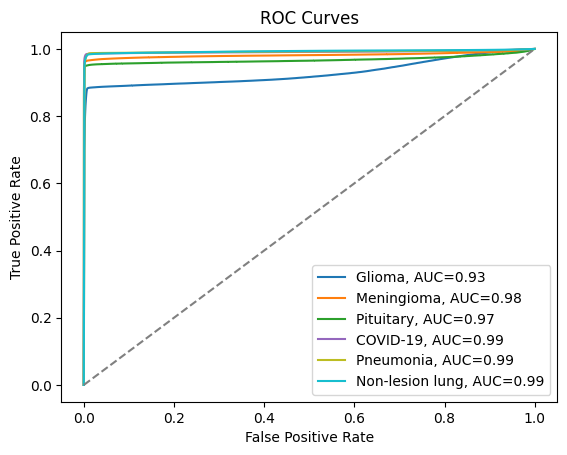

time: 1.06 s (started: 2025-01-05 17:58:44 +00:00)


In [ ]:
plot_roc_curves_from_auc(roc_aucs, model_names)